https://cicresearch.ca//CICDataset/CIC-UNSW/browse.php?t=1775399957621

| Label | Class | 
|---|---|
| 0 | Benign |
| 1 | Analysis |
| 2 | Backdoor |
| 3 | DoS |
| 4 | Exploits |
| 5 | Fuzzers |
| 6 | Generic |
| 7 | Reconnaissance |
| 8 | Shellcode |
| 9 | Worms |

## Setup
Import core libraries for data manipulation, visualization, and machine learning.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import scipy as sc

### Load Feature Data
Read the raw network flow features from `Data.csv` (UNSW-NB15 2024 dataset).

In [6]:
data_file = "~/Desktop/Coding projects for fun/Github improvement/IDS project/Data.csv"
# Load raw network flow features from CSV
data = pd.read_csv(data_file) 

# Confirm dimensions (rows, columns)
print(data.shape)


(447915, 76)


Inspect column names in the raw feature file.

In [8]:
data.columns

Index(['Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PSH Flag C

Preview the first few rows of the raw feature data.

In [10]:
data.head()

,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,214392,9,21,388.0,24564.0,194.0,0.0,43.111111,85.545959,1460.0,...,2,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2376792,9,3,752.0,0.0,188.0,0.0,83.555556,99.084700,0.0,...,4,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,131350,10,3,7564.0,0.0,1460.0,0.0,756.400000,690.497277,0.0,...,6,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,164796,6,3,770.0,0.0,385.0,0.0,128.333333,198.813145,0.0,...,2,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,163418,6,3,400.0,0.0,200.0,0.0,66.666667,103.279556,0.0,...,2,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Load Labels
Read traffic class labels from `label.csv`.

In [12]:
label_file = "~/Desktop/Coding projects for fun/Github improvement/IDS project/label.csv"
# Load class labels from separate CSV
label_df = pd.read_csv(label_file)
print(label_df.shape) 


(447915, 1)


Inspect column names in the label file.

In [14]:
label_df.loc[label_df["Label"]==8]

,Label
206,8
228,8
250,8
323,8
343,8
...,...
444785,8
445128,8
445274,8
445458,8


Preview the first few rows of the label file.

In [16]:
# Clean labels at source before merging
def merge_rare(label):
    if label == 1 or label == 2 or label == 9:
        return 10
    return label

label_df['Label'] = label_df['Label'].apply(merge_rare)

# Remap to 0–7
LABEL_REMAP = {0:0, 4:1, 5:2, 7:3, 6:4, 3:5, 8:6, 10:7}
label_df['Label'] = label_df['Label'].map(LABEL_REMAP)

print("\nRemapped label counts:")
print(label_df['Label'].value_counts().sort_index())

# Drop Label from data if it already exists to avoid duplication
if 'Label' in data.columns:
    data = data.drop(columns=['Label'])

# Now merge
df = pd.concat([data, label_df], axis=1)

print("\nFinal df label counts:")
print(df['Label'].value_counts().sort_index())
print("Final df shape:", df.shape)


Remapped label counts:
Label
0    358332
1     30951
2     29613
3     16735
4      4632
5      4467
6      2102
7      1083
Name: count, dtype: int64

Final df label counts:
Label
0    358332
1     30951
2     29613
3     16735
4      4632
5      4467
6      2102
7      1083
Name: count, dtype: int64
Final df shape: (447915, 77)


## Combine Features and Labels
Join the feature and label DataFrames column-wise into a single `df` and verify dtypes.

In [18]:
# Merge features and labels side-by-side into one DataFrame
#df = pd.concat([data, label], axis=1) 
df.dtypes

Flow Duration                   int64
Total Fwd Packet                int64
Total Bwd packets               int64
Total Length of Fwd Packet    float64
Total Length of Bwd Packet    float64
                               ...   
Idle Mean                     float64
Idle Std                      float64
Idle Max                      float64
Idle Min                      float64
Label                           int64
Length: 77, dtype: object

List all columns in the combined DataFrame.

In [20]:
df.drop_duplicates(inplace=True) 
print(df['Label'].value_counts())

Label
0    225003
1     30910
2     26395
3     12031
4      4496
5      4412
6      1848
7      1078
Name: count, dtype: int64


| Column | Description |
|---|---|
| Flow Duration | Total duration of the network flow in microseconds |
| Total Fwd Packet | Number of packets sent in the forward direction (client → server) |
| Total Bwd Packets | Number of packets sent in the backward direction (server → client) |
| Total Length of Fwd Packet | Total size in bytes of all forward packets |
| Total Length of Bwd Packet | Total size in bytes of all backward packets |
| Fwd Packet Length Max | Largest forward packet size in bytes |
| Fwd Packet Length Min | Smallest forward packet size in bytes |
| Fwd Packet Length Mean | Average forward packet size in bytes |
| Fwd Packet Length Std | Standard deviation of forward packet sizes |
| Bwd Packet Length Max | Largest backward packet size in bytes |
| Bwd Packet Length Min | Smallest backward packet size in bytes |
| Bwd Packet Length Mean | Average backward packet size in bytes |
| Bwd Packet Length Std | Standard deviation of backward packet sizes |
| Flow Bytes/s | Total bytes transferred per second in the flow |
| Flow Packets/s | Total packets transmitted per second in the flow |
| Flow IAT Mean | Average time between any two packets in the flow (Inter-Arrival Time) |
| Flow IAT Std | Standard deviation of inter-arrival times across the whole flow |
| Flow IAT Max | Longest gap between any two consecutive packets in the flow |
| Flow IAT Min | Shortest gap between any two consecutive packets in the flow |
| Fwd IAT Total | Total time between forward packets across the entire flow |
| Fwd IAT Mean | Average time between consecutive forward packets |
| Fwd IAT Std | Standard deviation of forward inter-arrival times |
| Fwd IAT Max | Longest gap between two consecutive forward packets |
| Fwd IAT Min | Shortest gap between two consecutive forward packets |
| Bwd IAT Total | Total time between backward packets across the entire flow |
| Bwd IAT Mean | Average time between consecutive backward packets |
| Bwd IAT Std | Standard deviation of backward inter-arrival times |
| Bwd IAT Max | Longest gap between two consecutive backward packets |
| Bwd IAT Min | Shortest gap between two consecutive backward packets |
| Fwd PSH Flags | Number of PSH flag packets in the forward direction (forces data flush) |
| Bwd PSH Flags | Number of PSH flag packets in the backward direction |
| Fwd URG Flags | Number of URG flag packets in the forward direction (urgent data) |
| Bwd URG Flags | Number of URG flag packets in the backward direction |
| Fwd Header Length | Total bytes used by headers in forward packets |
| Bwd Header Length | Total bytes used by headers in backward packets |
| Fwd Packets/s | Number of forward packets transmitted per second |
| Bwd Packets/s | Number of backward packets transmitted per second |
| Packet Length Min | Smallest packet size across the entire flow |
| Packet Length Max | Largest packet size across the entire flow |
| Packet Length Mean | Average packet size across the entire flow |
| Packet Length Std | Standard deviation of packet sizes across the entire flow |
| Packet Length Variance | Variance of packet sizes — higher variance can indicate unusual traffic |
| FIN Flag Count | Number of FIN flags — indicates connection termination attempts |
| SYN Flag Count | Number of SYN flags — indicates connection initiation attempts |
| RST Flag Count | Number of RST flags — indicates abrupt connection resets |
| PSH Flag Count | Number of PSH flags across the full flow |
| ACK Flag Count | Number of ACK flags — acknowledgement of received data |
| URG Flag Count | Number of URG flags across the full flow |
| CWR Flag Count | Number of CWR flags — congestion window reduced signal |
| ECE Flag Count | Number of ECE flags — explicit congestion notification echo |
| Down/Up Ratio | Ratio of download (backward) to upload (forward) traffic volume |
| Average Packet Size | Mean size of all packets in the flow |
| Fwd Segment Size Avg | Average segment size in the forward direction |
| Bwd Segment Size Avg | Average segment size in the backward direction |
| Fwd Bytes/Bulk Avg | Average bytes per bulk transfer in the forward direction |
| Fwd Packet/Bulk Avg | Average packets per bulk transfer in the forward direction |
| Fwd Bulk Rate Avg | Average bulk transfer rate in the forward direction |
| Bwd Bytes/Bulk Avg | Average bytes per bulk transfer in the backward direction |
| Bwd Packet/Bulk Avg | Average packets per bulk transfer in the backward direction |
| Bwd Bulk Rate Avg | Average bulk transfer rate in the backward direction |
| Subflow Fwd Packets | Average number of forward packets in a subflow |
| Subflow Fwd Bytes | Average number of forward bytes in a subflow |
| Subflow Bwd Packets | Average number of backward packets in a subflow |
| Subflow Bwd Bytes | Average number of backward bytes in a subflow |
| FWD Init Win Bytes | Number of bytes in the initial forward TCP window — reveals buffer size |
| Bwd Init Win Bytes | Number of bytes in the initial backward TCP window |
| Fwd Act Data Pkts | Number of forward packets that carried actual payload data |
| Fwd Seg Size Min | Minimum segment size observed in the forward direction |
| Active Mean | Average time the flow was active before going idle |
| Active Std | Standard deviation of active time periods |
| Active Max | Longest active period in the flow |
| Active Min | Shortest active period in the flow |
| Idle Mean | Average time the flow was idle between active periods |
| Idle Std | Standard deviation of idle time periods |
| Idle Max | Longest idle period in the flow |
| Idle Min | Shortest idle period in the flow |
| Label | Attack category — 0=Benign, 1=Analysis, 2=Backdoor, 3=DoS, 4=Exploits, 5=Fuzzers, 6=Generic, 7=Reconnaissance, 8=Shellcode, 9=Worms |

Check for missing (NaN) values across all columns.

In [23]:
df.isna().sum()

Flow Duration                 0
Total Fwd Packet              0
Total Bwd packets             0
Total Length of Fwd Packet    0
Total Length of Bwd Packet    0
                             ..
Idle Mean                     0
Idle Std                      0
Idle Max                      0
Idle Min                      0
Label                         0
Length: 77, dtype: int64

Preview the first few rows of the combined feature + label DataFrame.

In [25]:
print("First 5 rows of the combined_dataset:")
df.head()

First 5 rows of the combined_dataset:


,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,214392,9,21,388.0,24564.0,194.0,0.0,43.111111,85.545959,1460.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,2376792,9,3,752.0,0.0,188.0,0.0,83.555556,99.084700,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2,131350,10,3,7564.0,0.0,1460.0,0.0,756.400000,690.497277,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,164796,6,3,770.0,0.0,385.0,0.0,128.333333,198.813145,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
4,163418,6,3,400.0,0.0,200.0,0.0,66.666667,103.279556,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


DataFrame schema: dtypes, non-null counts, and memory usage.

In [27]:
print("\nInfo about the combined_dataset:")
df.info()


Info about the combined_dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 306173 entries, 0 to 447911
Data columns (total 77 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Flow Duration               306173 non-null  int64  
 1   Total Fwd Packet            306173 non-null  int64  
 2   Total Bwd packets           306173 non-null  int64  
 3   Total Length of Fwd Packet  306173 non-null  float64
 4   Total Length of Bwd Packet  306173 non-null  float64
 5   Fwd Packet Length Max       306173 non-null  float64
 6   Fwd Packet Length Min       306173 non-null  float64
 7   Fwd Packet Length Mean      306173 non-null  float64
 8   Fwd Packet Length Std       306173 non-null  float64
 9   Bwd Packet Length Max       306173 non-null  float64
 10  Bwd Packet Length Min       306173 non-null  float64
 11  Bwd Packet Length Mean      306173 non-null  float64
 12  Bwd Packet Length Std       306173 non-null

Descriptive statistics (mean, std, min, max, quartiles) for every numeric feature.

In [29]:
print("\nDescriptive statistics for the combined_dataset:")
print(df.describe())


Descriptive statistics for the combined_dataset:
       Flow Duration  Total Fwd Packet  Total Bwd packets  \
count   3.061730e+05     306173.000000      306173.000000   
mean    8.740835e+05         32.433167          38.881397   
std     5.879723e+06        153.768982         139.400931   
min     1.000000e+00          1.000000           0.000000   
25%     4.777000e+03          3.000000           2.000000   
50%     5.292200e+04          9.000000           7.000000   
75%     5.346830e+05         38.000000          37.000000   
max     1.199975e+08      20038.000000       11021.000000   

       Total Length of Fwd Packet  Total Length of Bwd Packet  \
count                3.061730e+05                3.061730e+05   
mean                 6.973511e+03                3.165550e+04   
std                  1.836319e+05                1.776357e+05   
min                  0.000000e+00                0.000000e+00   
25%                  7.400000e+01                0.000000e+00   
50%       

Count missing values per column in the combined DataFrame.

In [31]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Flow Duration                 0
Total Fwd Packet              0
Total Bwd packets             0
Total Length of Fwd Packet    0
Total Length of Bwd Packet    0
                             ..
Idle Mean                     0
Idle Std                      0
Idle Max                      0
Idle Min                      0
Label                         0
Length: 77, dtype: int64


### Class Distribution
Bar chart of sample counts per class — reveals the degree of class imbalance the models must handle.

/var/folders/9s/jwyj784906ndy4td5h3gqtnw0000gn/T/ipykernel_5290/2415061671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=label_col, palette='viridis')


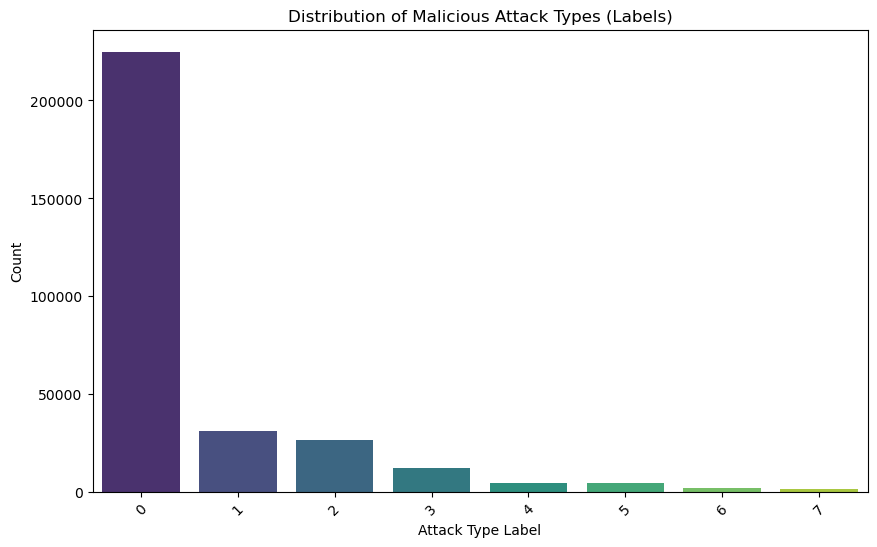

In [33]:
def plot_class_distribution(df, label_col='Label', title='Distribution of Malicious Attack Types (Labels)'):
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=label_col, palette='viridis')
    plt.title(title)
    plt.xlabel('Attack Type Label')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

plot_class_distribution(df)

### Correlation Heatmap
Full pairwise Pearson correlation matrix across all features — helps spot redundant columns before feature selection.

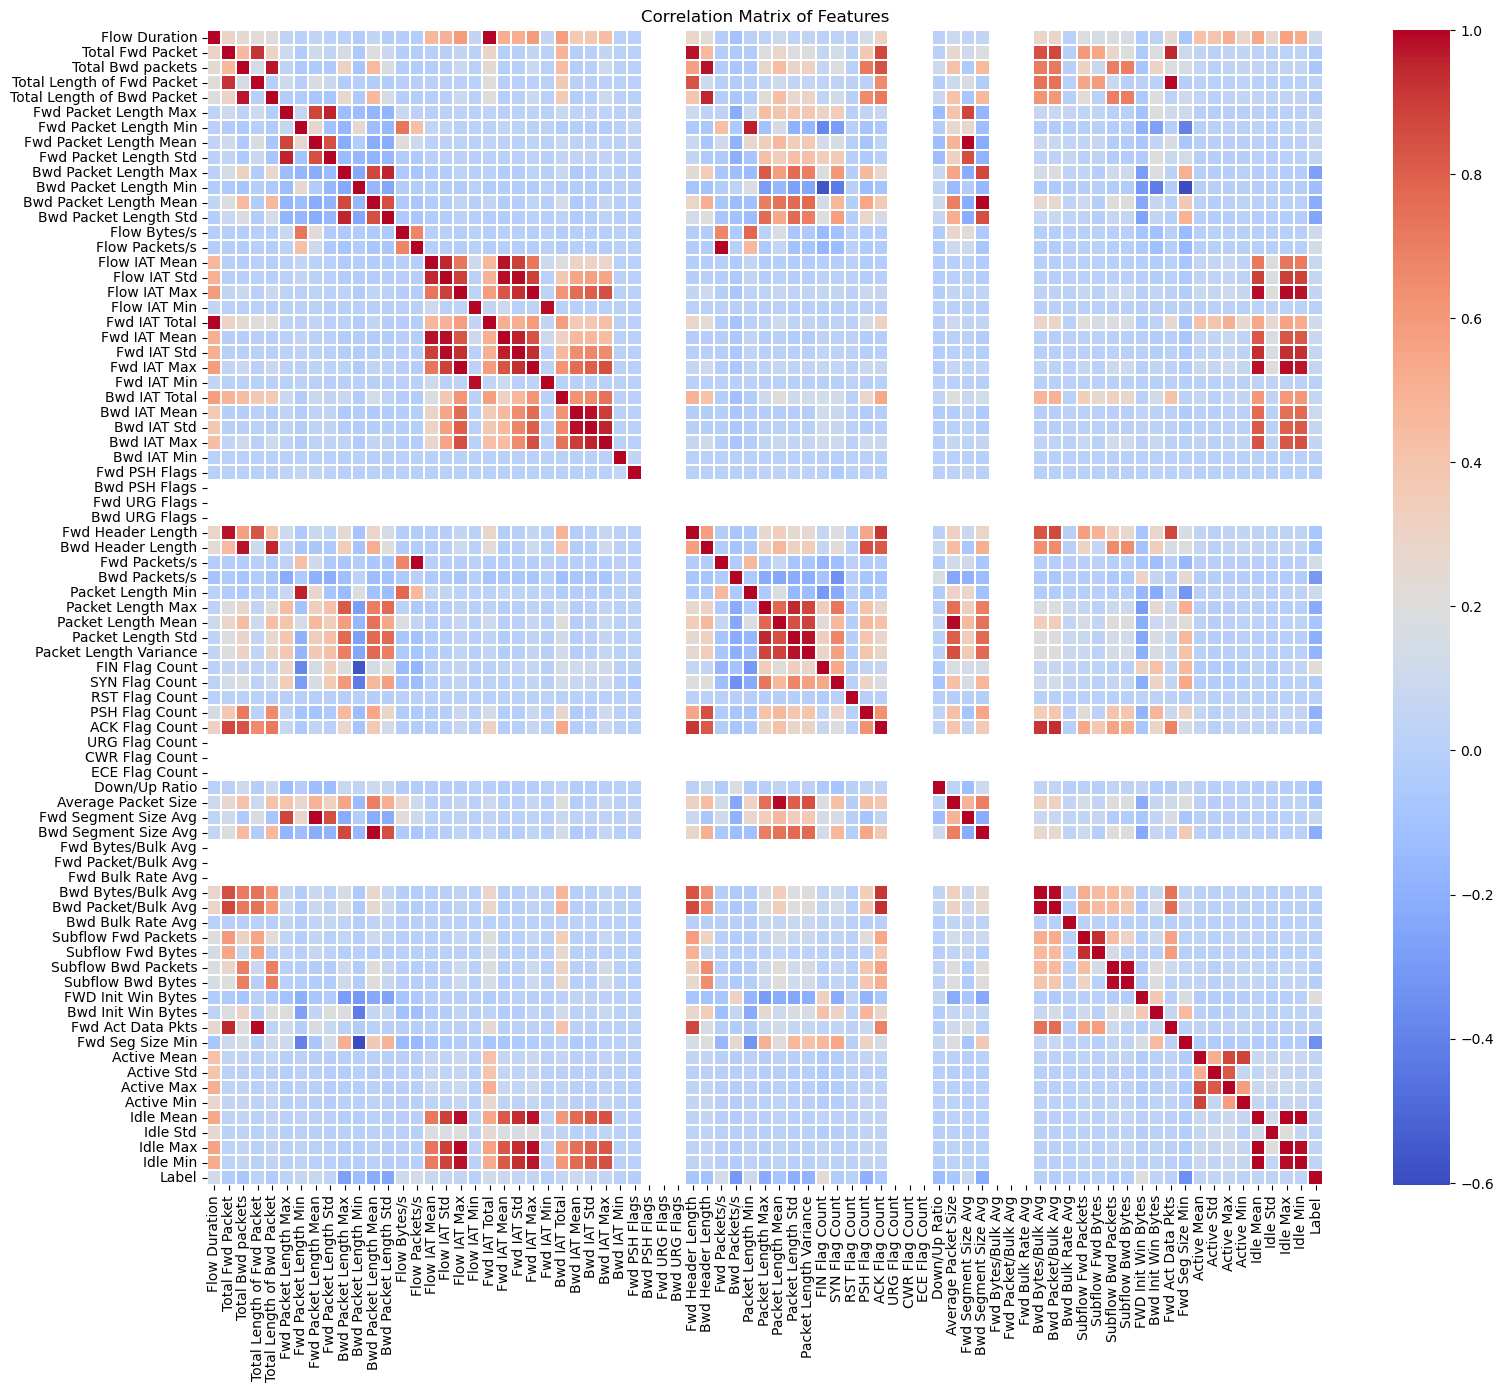

In [35]:
def plot_correlation_heatmap(df, title='Correlation Matrix of Features'):
    plt.figure(figsize=(18, 15))
    corr = df.corr()
    sns.heatmap(corr, cmap='coolwarm', fmt=".2f", linewidths=.05)
    plt.title(title)
    plt.show()

plot_correlation_heatmap(df)

### Global Plot Style + Label Map
Set a dark-theme matplotlib style and define the integer → class-name mapping used throughout the notebook.

In [37]:
#background colors for visualizations
plt.rcParams.update({
    'figure.facecolor': '#0f1117',  # outer figure bg — near-black, 1 shade darker than axes
    'axes.facecolor':   '#1a1d2e',  # plot area bg — deep navy, the "canvas"
    'axes.edgecolor':   '#2e3250',  # border around the axes box
    'axes.labelcolor':  '#c8cde8',  # x/y axis labels — cool lavender white
    'xtick.color':      '#7b82b0',  # x-axis tick labels — muted slate blue
    'ytick.color':      '#7b82b0',  # y-axis tick labels — same as xtick
    'text.color':       '#c8cde8',  # all other text (titles, annotations) — same as labels
    'grid.color':       '#2e3250',  # gridlines — same as axes edge, very subtle
    'grid.linewidth':   0.6,        # thin gridlines so they don't compete with data
    'font.family':      'monospace',
})
 
# Map integer class IDs to human-readable attack names
LABEL_MAP = {
    0: 'Benign',
    1: 'Exploits',
    2: 'Fuzzers',
    3: 'Recon',
    4: 'Generic',
    5: 'DoS',
    6: 'Shellcode',
    7: 'Rare_Attack',  # Analysis + Backdoor + Worms
}
 
# Assign a distinct color to each of the 10 attack classes
PALETTE = [
    '#4fc3f7',  # sky blue      — cool, high contrast; good for primary series
    '#ff6b6b',  # coral red     — warm accent; alerts, anomalies, fraud flags
    '#69db7c',  # mint green    — positive/normal state; benign traffic
    '#ffd43b',  # amber         — warning; mid-risk signals
    '#da77f2',  # orchid        — secondary categorical; model B or feature group
    '#ff922b',  # tangerine     — medium urgency; complements amber without clashing
    '#74c0fc',  # cornflower    — lighter sibling of sky blue; paired series
    '#f06595',  # rose          — distinct from coral; 8th category
]


Map numeric `Label` integers to human-readable class names in a new `Label_Name` column.

In [39]:
# Map numeric labels to names if Label column is numeric. np.float64 may not be needed here.
if df['Label'].dtype in [np.int64, np.float64]:
    # Translate numeric label to class name string
    df['Label_Name'] = df['Label'].map(LABEL_MAP)
else:
    df['Label_Name'] = df['Label']


## Exploratory Data Analysis
### Data Quality Audit
Scan for infinite values, missing values, and zero-variance columns.

In [41]:
# 1. INFINITE / MISSING VALUE CHECK
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("1. DATA QUALITY CHECK")
print("=" * 60)
 
# Isolate numeric columns — inf/NaN checks only apply to these 
    #looks for any columns with  numeric datatype
numeric_cols = df.select_dtypes(include=[np.number]).columns
 
# Infinite values per column
inf_counts = {}
for col in numeric_cols:
    # Count infinite values in this column. Loops through each column and stores in inf_counts. 
    n = np.isinf(df[col]).sum()
    if n > 0:
        inf_counts[col] = n
 
print(f"\n🔴 Columns with Inf values ({len(inf_counts)} found):") 
#if there are inf_counts we sort the items in the dictionary
if inf_counts:
    for col, n in sorted(inf_counts.items(), key=lambda x: -x[1]):
        print(f"{col:<40} {n:>8,} inf values")
else:
    print("None found ✅")
 
# Missing values
# Count NaN values per column
missing = df.isnull().sum() 
missing = missing[missing > 0]
print(f"\n🟡 Columns with NaN values ({len(missing)} found):") 
#looking for how many missing there are 
if len(missing):
    for col, n in missing.items():
        print(f"{col:<40} {n:>8,} missing")
else:
    print("None found ✅")
 
# Zero-variance columns
# Flag columns with only one unique value — zero discriminative power 
zero_var = [c for c in numeric_cols if df[c].nunique() <= 1] #List comprehension to find zero variance cols
print(f"\n⚪ Zero-variance columns ({len(zero_var)} found):")
if zero_var:
    for c in zero_var:
        print(f"   {c}")
else:
    print("None found ✅") 

missing

1. DATA QUALITY CHECK

🔴 Columns with Inf values (0 found):
None found ✅

🟡 Columns with NaN values (0 found):
None found ✅

⚪ Zero-variance columns (9 found):
   Bwd PSH Flags
   Fwd URG Flags
   Bwd URG Flags
   URG Flag Count
   CWR Flag Count
   ECE Flag Count
   Fwd Bytes/Bulk Avg
   Fwd Packet/Bulk Avg
   Fwd Bulk Rate Avg


Series([], dtype: int64)

### EDA 1 — Flow Packets/s vs Flow Bytes/s
Scatter plot colored by attack class to reveal traffic-rate signatures.

1. FLOW PACKETS/s vs FLOW BYTES/s SCATTER


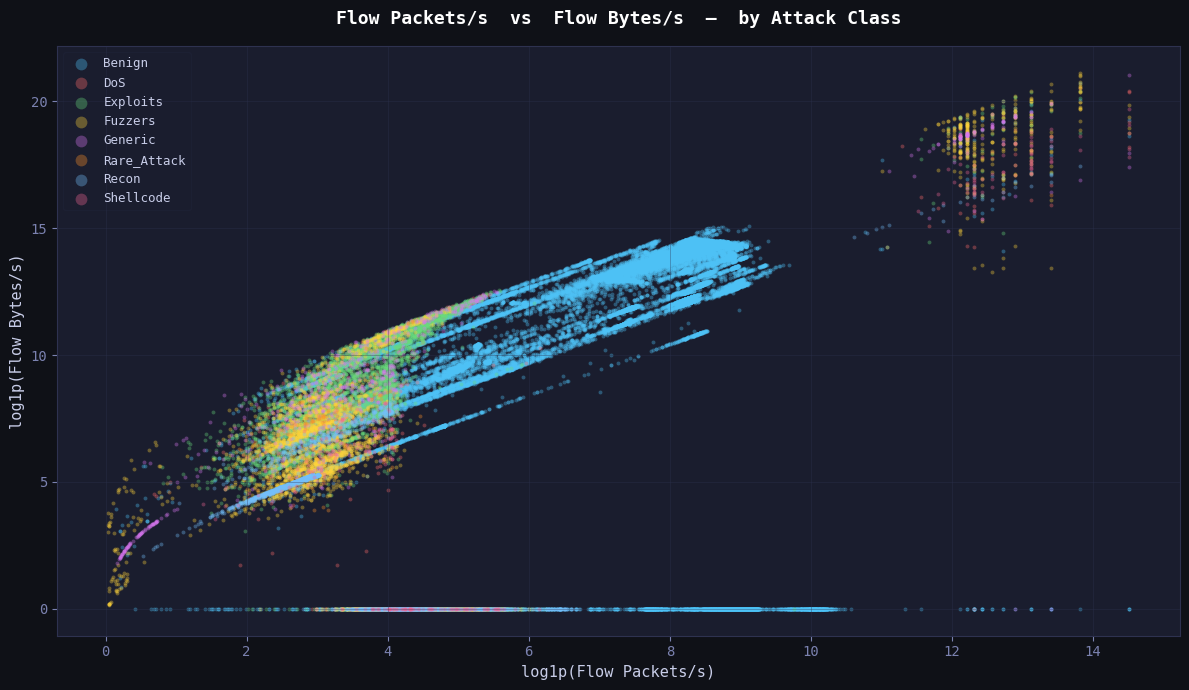

✅ Saved: scatter_packets_vs_bytes.png


In [43]:
# 2. FLOW PACKETS/s vs FLOW BYTES/s SCATTER (colored by label)
#setting the size and color of the figure 
print("=" * 60)
print("1. FLOW PACKETS/s vs FLOW BYTES/s SCATTER")
print("=" * 60) 
#setting the size and color of the figure
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0f1117')
 
# Replace inf before plotting
# Drop rows with inf/NaN in the plotted columns before rendering 
    #replaces infinite with nan and drops any nans in the subset 
plot_df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Flow Packets/s', 'Flow Bytes/s', 'Label_Name'])
 
# Sample for readability if dataset is large
# Cap at 50k points so the scatter plot stays readable
sample = plot_df.sample(min(50_000, len(plot_df)), random_state=42)
#loop through the label names to chart each attack class
for i, (label_name, group) in enumerate(sample.groupby('Label_Name')):
    ax.scatter(
        np.log1p(group['Flow Packets/s']),  # x-axis: log(1 + Flow Packets/s) to compress skewed data
        np.log1p(group['Flow Bytes/s']),    # y-axis: log(1 + Flow Bytes/s) to compress skewed data
        label=label_name,                   # legend entry for this traffic class
        alpha=0.35,                         # 35% opacity so overlapping points are visible
        s=8,                                # small marker size since you likely have many points
        color=PALETTE[i % len(PALETTE)],    # assign a unique color per label, cycling if needed
        linewidths=0                        # remove marker border/outline for cleaner look
    )
 
ax.set_xlabel('log1p(Flow Packets/s)', fontsize=11)        # x-axis label, font size 11
ax.set_ylabel('log1p(Flow Bytes/s)', fontsize=11)          # y-axis label, font size 11
ax.set_title('Flow Packets/s  vs  Flow Bytes/s  —  by Attack Class',
             fontsize=13,          # title font size
             pad=16,               # spacing between title and plot
             color='white',        # white title text (dark background theme)
             fontweight='bold')    # bold title
ax.legend(markerscale=3,           # enlarges legend markers so small s=8 dots are visible
          framealpha=0.15,         # semi-transparent legend background
          fontsize=9,              # legend text size
          facecolor='#1a1d2e',     # legend background color (matches dark theme)
          edgecolor='#2e3250')     # legend border color
ax.grid(True, alpha=0.4)           # show grid lines at 40% opacity
plt.tight_layout()                 # auto-adjust spacing so nothing gets clipped
plt.savefig('scatter_packets_vs_bytes.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✅ Saved: scatter_packets_vs_bytes.png")


### EDA 2 — Flow Duration by Class
Log-scaled box plots show how long each attack type sustains a network connection.

/var/folders/9s/jwyj784906ndy4td5h3gqtnw0000gn/T/ipykernel_5290/904263601.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


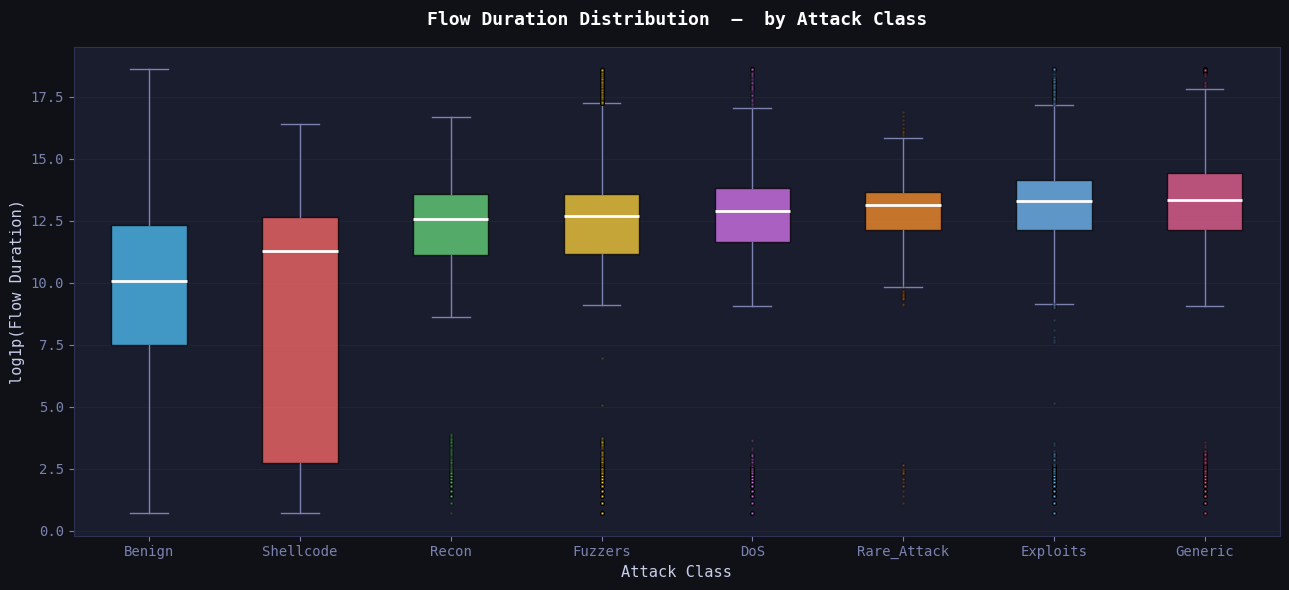

✅ Saved: boxplot_flow_duration.png


In [45]:
# 3. BOX PLOTS — Flow Duration by Attack Class
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1117')

plot_df2 = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Flow Duration', 'Label_Name'])
# log-scale duration so extreme outliers do not crush the y-axis
plot_df2['log_duration'] = np.log1p(plot_df2['Flow Duration'])

# sort attack classes by median log_duration so boxes appear in ascending order
order = plot_df2.groupby('Label_Name')['log_duration'].median().sort_values().index.tolist()

# creates the boxplots
bp = ax.boxplot(
    [plot_df2[plot_df2['Label_Name'] == lbl]['log_duration'].values for lbl in order],  # builds a list of arrays, one per attack class, in the specified order
    labels=order,                                         # sets the x-axis tick label for each box to the attack class name
    patch_artist=True,                                    # fills the boxes with color (required to apply facecolor later)
    medianprops=dict(color='white', linewidth=2),         # median line inside each box: white and slightly thick
    whiskerprops=dict(color='#7b82b0'),                   # whisker lines (extending to min/max within 1.5*IQR): muted purple
    capprops=dict(color='#7b82b0'),                       # cap lines at the ends of whiskers: same muted purple
    flierprops=dict(marker='o', markersize=2, alpha=0.2, linestyle='none')  # outlier points: small faint circles so they don't dominate
)

# apply palette colors to each box
for patch, color in zip(bp['boxes'], PALETTE):  # pairs each box with a color from the palette
    patch.set_facecolor(color)                  # fills the box with its assigned color
    patch.set_alpha(0.75)                       # makes the box slightly transparent

# match outlier dot colors to their respective box
for flier, color in zip(bp['fliers'], PALETTE): # pairs each set of outlier points with a color from the palette
    flier.set_markerfacecolor(color)            # colors the outlier dots to match their box

ax.set_xlabel('Attack Class', fontsize=11)
ax.set_ylabel('log1p(Flow Duration)', fontsize=11)
ax.set_title('Flow Duration Distribution  —  by Attack Class',
             fontsize=13, pad=16, color='white', fontweight='bold')
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('boxplot_flow_duration.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✅ Saved: boxplot_flow_duration.png")
 
 


### EDA 3 — TCP Flag Rates by Class
Stacked bar of mean TCP flag counts per class — SYN/ACK ratios expose scan and DoS patterns.

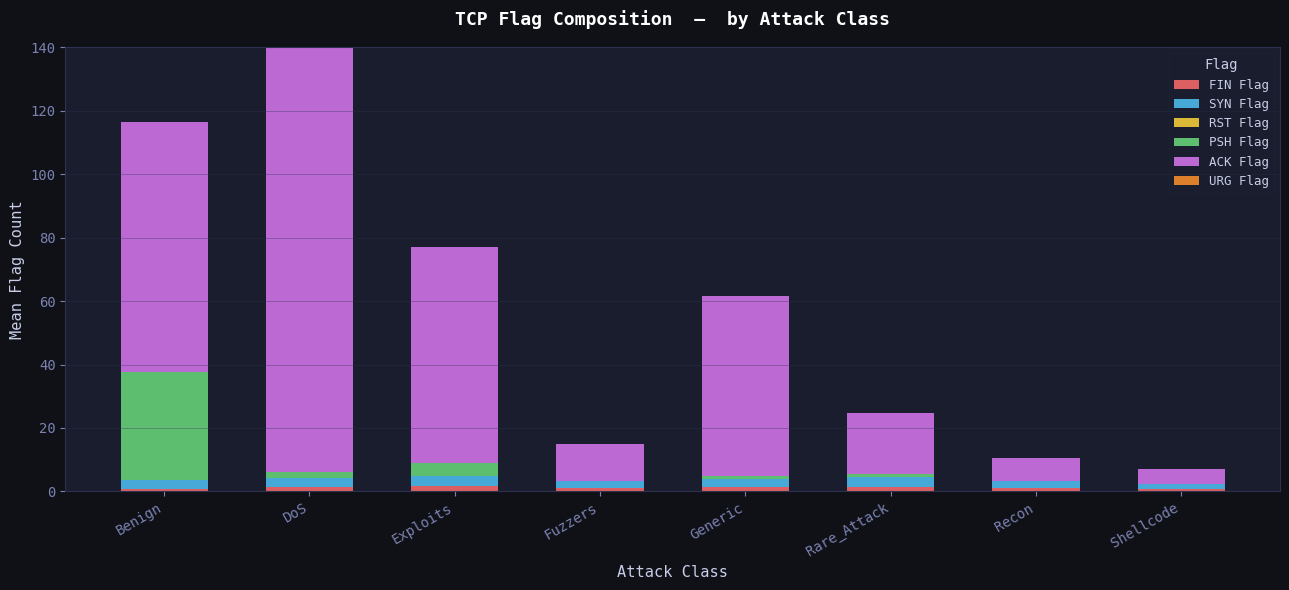

✅ Saved: flags_stacked_bar.png


In [47]:
# 4. TCP FLAG STACKED BAR — by Attack Class
# ══════════════════════════════════════════════════════════════════════════════
flag_cols = ['FIN Flag Count', 'SYN Flag Count', 'RST Flag Count',
             'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count']
# Guard against flag columns dropped in feature selection
flag_cols = [c for c in flag_cols if c in df.columns]
 
# Average flag counts per class to reveal TCP signature patterns
flag_df = df.groupby('Label_Name')[flag_cols].mean()
 
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1117')
 
flag_colors = ['#ff6b6b', '#4fc3f7', '#ffd43b', '#69db7c', '#da77f2', '#ff922b']


bottom = np.zeros(len(flag_df))  # initialize a zero baseline for each bar (one per row in flag_df)
for i, col in enumerate(flag_cols):
    ax.bar(
        flag_df.index,                        # x-axis positions (the attack class labels)
        flag_df[col],                         # height of this segment for each bar
        bottom=bottom,                        # start this segment where the previous one ended (stacking)
        label=col.replace(' Count', ''),      # strip ' Count' from column name for a cleaner legend entry
        color=flag_colors[i % len(flag_colors)],  # assign a unique color per flag type, cycling if needed
        alpha=0.85,                           # slight transparency
        width=0.6                             # bar width
    )
    bottom += flag_df[col].values             # shift the baseline up by this segment's values so the next flag stacks on top
 
ax.set_xlabel('Attack Class', fontsize=11)
ax.set_ylabel('Mean Flag Count', fontsize=11)
ax.set_title('TCP Flag Composition  —  by Attack Class',
             fontsize=13, pad=16, color='white', fontweight='bold')
ax.legend(title='Flag', framealpha=0.15, facecolor='#1a1d2e',
          edgecolor='#2e3250', fontsize=9)
ax.grid(True, axis='y', alpha=0.4)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('flags_stacked_bar.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✅ Saved: flags_stacked_bar.png")
 


### EDA 4 — Inter-Arrival Time by Class
Violin plots of log-scaled IAT Mean reveal burstiness and timing differences across attack types.

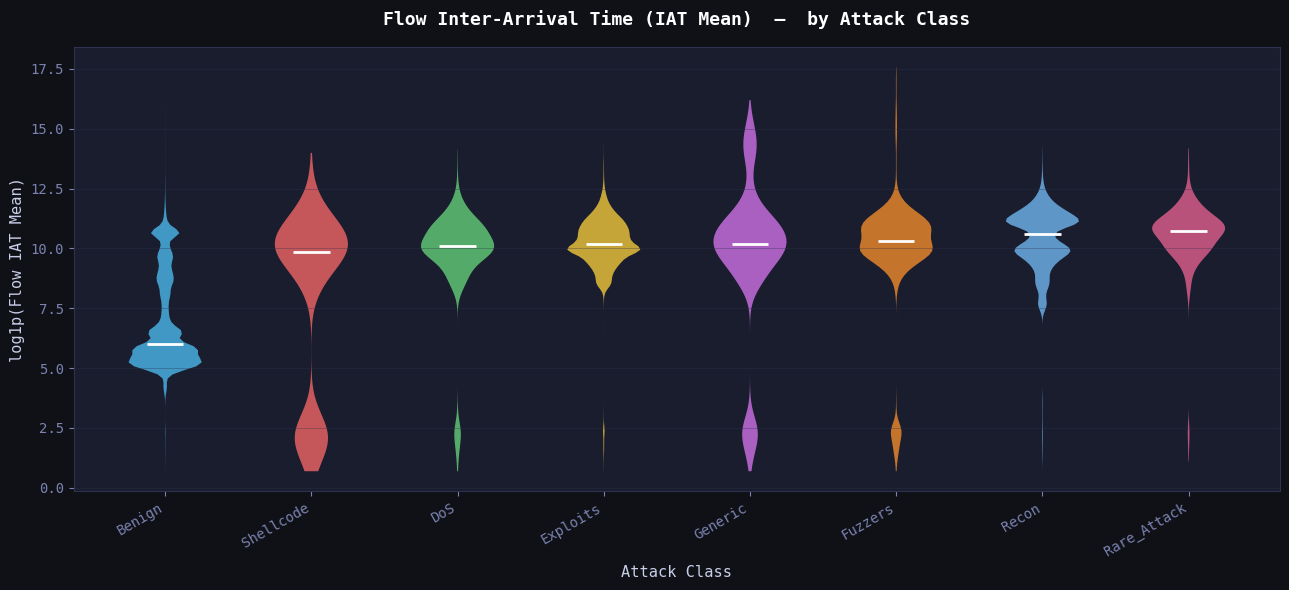

✅ Saved: violin_iat_mean.png


In [49]:
# 5. VIOLIN PLOTS — Flow IAT Mean by Attack Class
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1117')
 
plot_df3 = df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=['Flow IAT Mean', 'Label_Name']).copy()
# Clip negatives then log-scale to handle extreme IAT values
plot_df3['log_iat'] = np.log1p(plot_df3['Flow IAT Mean'].clip(lower=0))
 
# Clip negatives then log-scale to handle extreme IAT values
order3 = plot_df3.groupby('Label_Name')['log_iat'].median().sort_values().index.tolist()
 
parts = ax.violinplot(
    # Clip negatives then log-scale to handle extreme IAT values
    [plot_df3[plot_df3['Label_Name'] == lbl]['log_iat'].values for lbl in order3],
    positions=range(len(order3)),
    showmedians=True,
    showextrema=False
)
 
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i % len(PALETTE)])
    pc.set_alpha(0.75)
parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)
 
ax.set_xticks(range(len(order3)))
ax.set_xticklabels(order3, rotation=30, ha='right')
ax.set_xlabel('Attack Class', fontsize=11)
ax.set_ylabel('log1p(Flow IAT Mean)', fontsize=11)
ax.set_title('Flow Inter-Arrival Time (IAT Mean)  —  by Attack Class',
             fontsize=13, pad=16, color='white', fontweight='bold')
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('violin_iat_mean.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✅ Saved: violin_iat_mean.png")
 


### EDA 5 — Mutual Information Scores
Rank features by mutual information with the label to identify the strongest predictors.


6. MUTUAL INFORMATION SCORES (top 20 features)


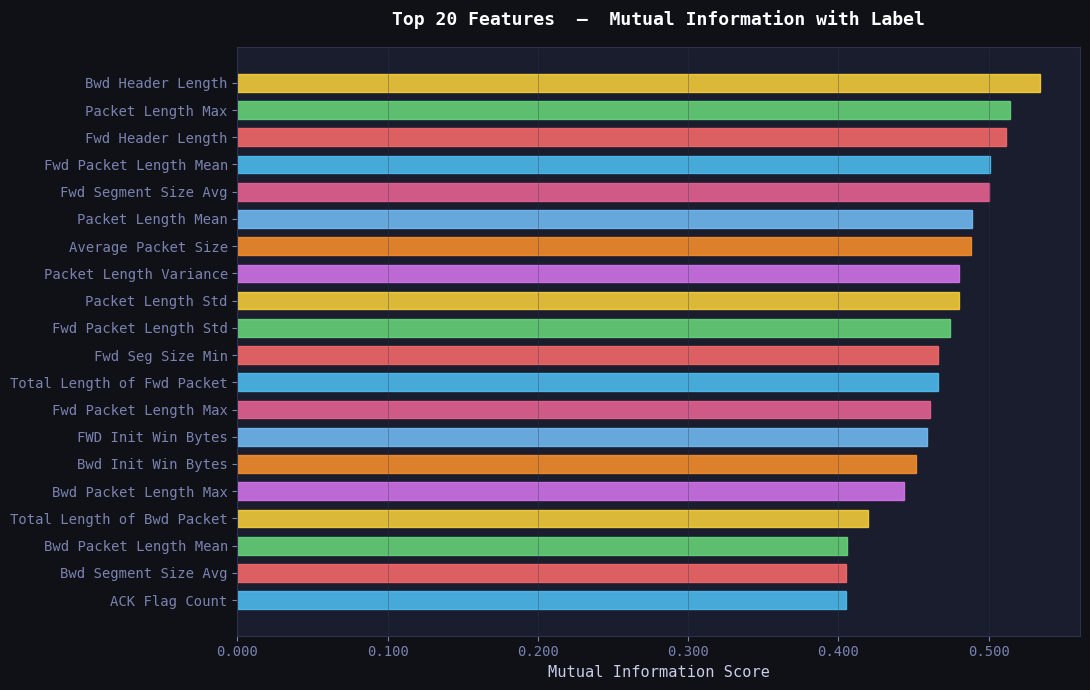

✅ Saved: mutual_information.png

📊 Top 20 features by mutual information:
   Bwd Header Length                             0.5341
   Packet Length Max                             0.5142
   Fwd Header Length                             0.5113
   Fwd Packet Length Mean                        0.5010
   Fwd Segment Size Avg                          0.5001
   Packet Length Mean                            0.4887
   Average Packet Size                           0.4884
   Packet Length Variance                        0.4805
   Packet Length Std                             0.4805
   Fwd Packet Length Std                         0.4744
   Fwd Seg Size Min                              0.4664
   Total Length of Fwd Packet                    0.4661
   Fwd Packet Length Max                         0.4612
   FWD Init Win Bytes                            0.4591
   Bwd Init Win Bytes                            0.4514
   Bwd Packet Length Max                         0.4436
   Total Length of Bwd Packet 

In [51]:
# 6. MUTUAL INFORMATION SCORES
# ══════════════════════════════════════════════════════════════════════════════ 
import matplotlib.ticker as ticker
print("\n" + "=" * 60)
print("6. MUTUAL INFORMATION SCORES (top 20 features)")
print("=" * 60)
from sklearn.feature_selection import mutual_info_classif
mi_df = df.replace([np.inf, -np.inf], np.nan).dropna()
feature_cols = [c for c in numeric_cols if c != 'Label'] #all non-tgt variable columns
X_mi = mi_df[feature_cols].fillna(0)
y_mi = mi_df['Label']
 
# Score each feature by how much information it shares with the label
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
# Rank all features from most to least informative
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)
# Keep the 20 highest-MI features for visualisation
top20 = mi_series.head(20)
 
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f1117')
 
bars = ax.barh(top20.index[::-1], top20.values[::-1],
               color=PALETTE[0], alpha=0.85, height=0.65)
 
# Color gradient from low to high
for i, bar in enumerate(bars):
    bar.set_color(PALETTE[i % len(PALETTE)])
 
ax.set_xlabel('Mutual Information Score', fontsize=11)
ax.set_title('Top 20 Features  —  Mutual Information with Label',
             fontsize=13, pad=16, color='white', fontweight='bold')
ax.grid(True, axis='x', alpha=0.4)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✅ Saved: mutual_information.png")
 
print("\n📊 Top 20 features by mutual information:")
for feat, score in top20.items():
    print(f"   {feat:<45} {score:.4f}")
 


### EDA 6 — Mean Feature Values per Class
Normalized heatmap of the top-15 MI features per class — reveals class-specific feature signatures.

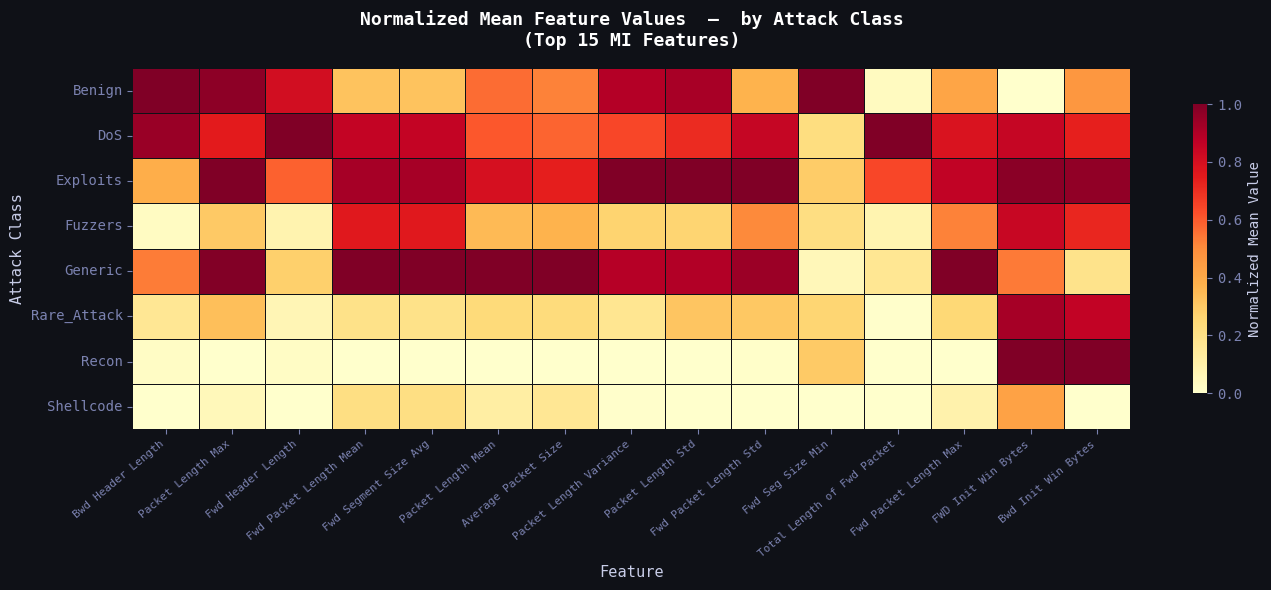

✅ Saved: heatmap_class_means.png

✅ All EDA plots complete!


In [53]:
# 7. MEAN FEATURE VALUES PER CLASS (heatmap)
# ══════════════════════════════════════════════════════════════════════════════
# Pick most informative features from MI scores
# Select top 15 MI features for the class-mean heatmap
top_features = top20.head(15).index.tolist()
 
# Compute mean value of each top feature grouped by attack class
class_means = df.replace([np.inf, -np.inf], np.nan).groupby('Label_Name')[top_features].mean()
 
# Normalize each feature to 0-1 for readability
# Min-max normalise so features on different scales are comparable
class_means_norm = (class_means - class_means.min()) / (class_means.max() - class_means.min() + 1e-9)
 
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')
 
sns.heatmap(
    # Min-max normalise so features on different scales are comparable
    class_means_norm,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='#0f1117',
    annot=False,
    cbar_kws={'shrink': 0.8, 'label': 'Normalized Mean Value'}
)
 
ax.set_title('Normalized Mean Feature Values  —  by Attack Class\n(Top 15 MI Features)',
             fontsize=13, pad=16, color='white', fontweight='bold')
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Attack Class', fontsize=11)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_class_means.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✅ Saved: heatmap_class_means.png")
 
print("\n✅ All EDA plots complete!")


Verify the current column list after exploratory analysis transforms.

In [55]:
df.columns

Index(['Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PSH Flag C

In [56]:
# Ratio features — very powerful for IDS
# Ratio features — remapped to actual UNSW-NB15 2024 column names
# Packet asymmetry — uneven fwd/bwd counts signal attacks
df['Fwd_Bwd_Packet_Ratio'] = (
    df['Total Fwd Packet'] / 
    (df['Total Bwd packets'] + 1)
)
# Byte asymmetry — extreme ratios indicate data exfiltration
df['Fwd_Bwd_Bytes_Ratio'] = (
    df['Total Length of Fwd Packet'] / 
    (df['Total Length of Bwd Packet'] + 1)
)
# Average payload size — very small values suggest scanning
df['Bytes_Per_Packet'] = (
    (df['Total Length of Fwd Packet'] + df['Total Length of Bwd Packet']) /
    (df['Total Fwd Packet'] + df['Total Bwd packets'] + 1)
)
# Header_To_Payload_Ratio dropped — no header length cols in this dataset

# Sum of active TCP flags — spikes indicate flag manipulation
df['Total_Flags'] = (
    df['FIN Flag Count'] + df['SYN Flag Count'] +
    df['PSH Flag Count'] + df['ACK Flag Count']
) 

# Spread in forward packet sizes
df['Fwd_Packet_Length_Range'] = (
    df['Fwd Packet Length Max'] - df['Fwd Packet Length Min']
)
# Spread in backward packet sizes
df['Bwd_Packet_Length_Range'] = (
    df['Bwd Packet Length Max'] - df['Bwd Packet Length Min']
) 
# Active-to-idle ratio — sustained traffic differs from bursty attacks
df['Active_Idle_Ratio'] = (
    df['Active Mean'] /
    (df['Idle Mean'] + 1)
) 
 
# TCP initial window asymmetry — can indicate SYN flood or evasion
df['Init_Win_Ratio'] = (
    df['FWD Init Win Bytes'] /
    (df['Bwd Init Win Bytes'] + 1)
)
# Note: RST and URG also absent — only FIN/SYN/PSH/ACK available   
# Remove string label column; 'Label' int column is kept
df = df.drop(columns=['Label_Name'])


## Feature Engineering
### Step 1 — Remove Low-Variance Features
Drop columns with near-zero variance (threshold = 0.01) — they carry no discriminative signal.

In [58]:
# Drop zero-variance or near-constant columns
from sklearn.feature_selection import VarianceThreshold

# Separate label and identify numeric-only feature columns
feature_cols = df.drop('Label', axis=1) 
#gets all numeric cols
numeric_cols = feature_cols.select_dtypes(include='number').columns

# Fit variance selector on numeric features only
# Drop features whose variance is below 0.01
selector = VarianceThreshold(threshold=0.01)
# Learn which columns meet the variance threshold
selector.fit(df[numeric_cols])

# Find low-variance columns among the numeric ones
# ID columns that failed the threshold
low_var_cols = numeric_cols[~selector.get_support()].tolist()
print("Dropping low variance cols:", low_var_cols)

# Remove low-variance columns permanently
df.drop(columns=low_var_cols, inplace=True)

Dropping low variance cols: ['Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'URG Flag Count', 'CWR Flag Count', 'ECE Flag Count', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg']


### Step 2 — Impute Infinite / Missing Values
Replace ±inf with NaN then fill each column with its median.

In [60]:
# Replace inf with NaN then impute with median
# Convert inf to NaN so standard imputation can handle them
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# Fill NaN with column medians — robust to remaining outliers
df.fillna(df.median(numeric_only=True), inplace=True)

### Step 3 — Drop Highly Correlated Features
Remove one column from each pair with Pearson r > 0.95 to reduce multicollinearity.

In [62]:
# Remove one of each pair with correlation > 0.95
numeric_cols = df.drop('Label', axis=1).select_dtypes(include='number').columns

# Build absolute Pearson correlation matrix
corr_matrix = df[numeric_cols].corr().abs()
# Keep only the upper triangle to avoid counting each pair twice
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Flag one column from each pair with r > 0.95
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Dropping {len(to_drop)} highly correlated features:", to_drop)
# Remove the redundant highly-correlated columns
df.drop(columns=to_drop, inplace=True)


Dropping 28 highly correlated features: ['Total Length of Bwd Packet', 'Fwd Packet Length Std', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Packet Length Min', 'Packet Length Variance', 'Average Packet Size', 'Fwd Segment Size Avg', 'Bwd Segment Size Avg', 'Bwd Packet/Bulk Avg', 'Subflow Bwd Bytes', 'Fwd Act Data Pkts', 'Idle Mean', 'Idle Max', 'Idle Min', 'Bytes_Per_Packet', 'Total_Flags', 'Fwd_Packet_Length_Range', 'Bwd_Packet_Length_Range', 'Active_Idle_Ratio']


### Step 4 — Drop Low-Signal Feature Groups
Remove bulk/subflow, active/idle, and redundant IAT columns confirmed to carry no discriminative signal.

In [64]:
# Drop confirmed low-signal groups
bulk_subflow = ['Bwd Bytes/Bulk Avg', 'Bwd Bulk Rate Avg',
                'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets']
active_idle  = ['Active Mean', 'Active Std', 'Active Max', 'Active Min',
                'Idle Mean', 'Idle Std', 'Active_Idle_Ratio']
iat_redundant = ['Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
                 'Fwd IAT Total', 'Bwd IAT Total', 'Bwd IAT Mean',
                 'Bwd IAT Max', 'Bwd IAT Min']

to_drop = bulk_subflow + active_idle + iat_redundant
to_drop = [c for c in to_drop if c in df.columns]
df.drop(columns=to_drop, inplace=True)
print(f"After group drops: {df.drop('Label', axis=1).shape[1]} features remaining")


After group drops: 28 features remaining


### Step 5 — Train / Test Split
Split 80 / 20 stratified by class. SMOTE is applied in the next step to the training set only.

In [66]:
from sklearn.model_selection import train_test_split

X = df.drop('Label', axis=1)
y = df['Label']

# 80 / 20 stratified split — SMOTE is applied to training set only in the next step
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test set:     {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nClass distribution (train):\n{pd.Series(y_train).value_counts().sort_index()}')


Training set: (244938, 28)  (80%)
Test set:     (61235, 28)  (20%)

Class distribution (train):
Label
0    180002
1     24728
2     21116
3      9625
4      3597
5      3530
6      1478
7       862
Name: count, dtype: int64


### Step 7 — MI Feature Selection
Fit `mutual_info_classif` on `X_train` / `y_train` only, then apply the resulting `top_features` mask to `X_train`, `X_train_res`, and `X_test`. Fitting on real (pre-SMOTE) labels prevents synthetic rows from influencing which features are retained.

Feature selection used mutual_info_classif from scikit-learn as the final ranking step, after variance thresholding, correlation filtering, and manual removal of redundant feature groups. Mutual information was chosen over correlation-based alternatives because it is non-parametric and captures non-linear statistical dependencies between each feature and the class label, an important property for network flow data, where relationships between features such as packet rates, byte counts, and attack categories are rarely linear. Each feature receives a score reflecting how much knowing its value reduces uncertainty about the label, with zero indicating complete independence. Because mutual information evaluates features independently, redundant features can both score highly even when they carry the same underlying signal; applying it after the correlation filter ensures the ranking reflects genuine information content rather than shared variance. The top 20 features by MI score were retained for model training, and notably three of the five engineered ratio features ranked among them, validating that domain-informed feature construction added discriminative signal beyond what the raw columns provided.

In [68]:
from sklearn.feature_selection import mutual_info_classif

# Fit on training labels only — test set has no influence on feature selection
mi_scores = mutual_info_classif(
    X_train.select_dtypes(include='number'), y_train, random_state=42
) 
#pandas series of the mi_scores best to worst
mi_series = pd.Series(mi_scores, index=X_train.select_dtypes(include='number').columns)
mi_series = mi_series.sort_values(ascending=False)
#allows us to list our features in mi_series
top_features = mi_series.head(20).index.tolist()
print("Top 20 features by MI (training data only):")
print(mi_series.head(20).to_string())

# Apply the same mask to both splits — scaler and SMOTE see identical columns
X_train = X_train[top_features]
X_test  = X_test[top_features]
print(f"\nX_train shape after MI selection: {X_train.shape}")
print(f"X_test  shape after MI selection: {X_test.shape}")


Top 20 features by MI (training data only):
Fwd_Bwd_Bytes_Ratio           0.520168
Packet Length Max             0.510896
Fwd Packet Length Mean        0.494901
Packet Length Mean            0.474868
Packet Length Std             0.471971
Total Length of Fwd Packet    0.465913
Fwd Seg Size Min              0.461156
Fwd Packet Length Max         0.458931
FWD Init Win Bytes            0.456936
Bwd Init Win Bytes            0.449868
Init_Win_Ratio                0.445345
Bwd Packet Length Max         0.441308
Fwd_Bwd_Packet_Ratio          0.440139
ACK Flag Count                0.403921
Bwd Packet Length Mean        0.400639
Total Fwd Packet              0.399876
Bwd Packets/s                 0.349980
Flow IAT Mean                 0.339226
Flow Packets/s                0.331929
Flow Bytes/s                  0.295311

X_train shape after MI selection: (244938, 20)
X_test  shape after MI selection: (61235, 20)


In [69]:
# Log the selected features with their MI scores
print("Selected features (MI top-20):")
for i, feat in enumerate(top_features, 1):
    print(f"  {i:2d}. {feat:<40}  MI={mi_series[feat]:.4f}")
print(f"\nTotal: {len(top_features)} features selected")

Selected features (MI top-20):
   1. Fwd_Bwd_Bytes_Ratio                       MI=0.5202
   2. Packet Length Max                         MI=0.5109
   3. Fwd Packet Length Mean                    MI=0.4949
   4. Packet Length Mean                        MI=0.4749
   5. Packet Length Std                         MI=0.4720
   6. Total Length of Fwd Packet                MI=0.4659
   7. Fwd Seg Size Min                          MI=0.4612
   8. Fwd Packet Length Max                     MI=0.4589
   9. FWD Init Win Bytes                        MI=0.4569
  10. Bwd Init Win Bytes                        MI=0.4499
  11. Init_Win_Ratio                            MI=0.4453
  12. Bwd Packet Length Max                     MI=0.4413
  13. Fwd_Bwd_Packet_Ratio                      MI=0.4401
  14. ACK Flag Count                            MI=0.4039
  15. Bwd Packet Length Mean                    MI=0.4006
  16. Total Fwd Packet                          MI=0.3999
  17. Bwd Packets/s                      

In [70]:
### Step 6 — SMOTE
#Oversample minority classes to 10% of the majority count on the training set only — test set is untouched.
from imblearn.over_sampling import SMOTE

# Cap minority classes at 10% of majority to avoid over-generation
majority_count = pd.Series(y_train).value_counts().max()
smote_target   = int(majority_count * 0.10)
# Oversample only classes below smote_target; majority classes are excluded and unchanged.
sampling_strategy = {
    label: max(count, smote_target)
    for label, count in pd.Series(y_train).value_counts().items()
    if count < smote_target
}

# Fit and resample on MI-selected training features only — test set is untouched
sm = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f'Before SMOTE: {X_train.shape}')
print(f'After SMOTE:  {X_train_res.shape}')
print(f'\ny_train value counts:\n{pd.Series(y_train).value_counts().sort_index()}')
print(f'\ny_train_res value counts:\n{pd.Series(y_train_res).value_counts().sort_index()}')

Before SMOTE: (244938, 20)
After SMOTE:  (315846, 20)

y_train value counts:
Label
0    180002
1     24728
2     21116
3      9625
4      3597
5      3530
6      1478
7       862
Name: count, dtype: int64

y_train_res value counts:
Label
0    180002
1     24728
2     21116
3     18000
4     18000
5     18000
6     18000
7     18000
Name: count, dtype: int64


### Step 8 — Feature Scaling
Fit `RobustScaler` on the real training data (resistant to outliers) and transform all three splits.

In [72]:
from sklearn.preprocessing import RobustScaler


#X_train_res = X_train_res[top_features]

# RobustScaler uses median/IQR — resistant to the outliers common in network flow data
scaler = RobustScaler()
# Fit on real training data only — keeps synthetic SMOTE rows out of the scaling distribution
X_train_scaled = scaler.fit_transform(X_train)
# Transform SMOTE-balanced train and test with the same fitted scaler
X_train_res_scaled = scaler.transform(X_train_res)
X_test_scaled = scaler.transform(X_test) 


## Modeling Imports
Import sklearn metrics, cross-validation utilities, and PyTorch modules shared by all models.

In [74]:
# ── Core ──────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn — shared utilities ─────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc
) 
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize

# ── Cross Validation ───────────────────────────────────────────────────────────
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV
)

# ── Scipy distributions for RandomizedSearchCV param distributions ─────────────
from scipy.stats import randint, uniform, loguniform

# ── Logistic Regression ────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression

# ── Random Forest ─────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


# Logistic Regression

#### Logistic Regression — Fit & Predict
Define and fit logistic regression with SAGA solver and balanced class weights.

In [77]:
# SMOTE was applied once in Step 6 on the full training set rather than inside
# each CV fold — this avoids re-running it 24 times and cuts search time significantly.
lr_cv_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', LogisticRegression(
        solver='saga', # saga handles multiclass + large datasets efficiently
        max_iter=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        tol=1e-2, # loosened tolerance to speed up convergence
    ))
])

# loguniform samples C on a log scale, giving equal coverage to small and large values

param_dist_lr = {'model__C': loguniform(1e-3, 10),}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


gs_lr = RandomizedSearchCV(
    lr_cv_pipeline,
    param_distributions=param_dist_lr,
    n_iter=8,
    cv=skf,
    scoring={
        'accuracy':    'accuracy',
        'macro_f1':    'f1_macro',
        'weighted_f1': 'f1_weighted',
    },
    refit='macro_f1',
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
    random_state=42
)
# SMOTE already ran once in Step 6 — search directly on the balanced data
gs_lr.fit(X_train, y_train)

print('=== Logistic Regression — RandomizedSearchCV ===')
print(f"Best params:      {gs_lr.best_params_}")
print(f"Best Macro F1:    {gs_lr.best_score_:.4f}")

res = gs_lr.cv_results_
b   = gs_lr.best_index_
print(f"Train Accuracy:   {res['mean_train_accuracy'][b]:.4f} ± {res['std_train_accuracy'][b]:.4f}")
print(f"Val  Accuracy:    {res['mean_test_accuracy'][b]:.4f} ± {res['std_test_accuracy'][b]:.4f}")
print(f"Train Macro F1:   {res['mean_train_macro_f1'][b]:.4f} ± {res['std_train_macro_f1'][b]:.4f}")
print(f"Val  Macro F1:    {res['mean_test_macro_f1'][b]:.4f} ± {res['std_test_macro_f1'][b]:.4f}")
print(f"Val  Weighted F1: {res['mean_test_weighted_f1'][b]:.4f} ± {res['std_test_weighted_f1'][b]:.4f}")


Fitting 3 folds for each of 8 candidates, totalling 24 fits
=== Logistic Regression — RandomizedSearchCV ===
Best params:      {'model__C': 0.03148911647956861}
Best Macro F1:    0.0460
Train Accuracy:   0.1327 ± 0.0027
Val  Accuracy:    0.1323 ± 0.0027
Train Macro F1:   0.0453 ± 0.0011
Val  Macro F1:    0.0460 ± 0.0013
Val  Weighted F1: 0.1882 ± 0.0044


#### Logistic Regression — Cross-Validation
5-fold stratified cross-validation on the training set.

In [79]:
# Final inference pipeline — no SMOTE since X_train_res is already balanced.
# Uses best C found by gs_lr; scaler fit on training data only to prevent leakage.
lr_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', LogisticRegression(
        C=gs_lr.best_params_['model__C'],
        solver='saga',
        max_iter=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        tol=1e-2,
    ))])
# Fit on SMOTE-balanced unscaled training data. pipeline handles scaling internally. Only place the SMOTE data will be used is in fit
lr_pipeline.fit(X_train_res, y_train_res)
# Generate class predictions on the held-out test set
y_pred_lr = lr_pipeline.predict(X_test)

print('=== Logistic Regression — Train vs Test Score (overfitting check) ===')
print(f'  Training Score: {lr_pipeline.score(X_train, y_train):.4f}')
print(f'  Testing Score:  {lr_pipeline.score(X_test, y_test):.4f}')
print()
print('=== Logistic Regression — Classification Report (Test Set) ===')
print(classification_report(
    y_test, y_pred_lr,
    target_names=list(LABEL_MAP.values()),
    digits=4
))

=== Logistic Regression — Train vs Test Score (overfitting check) ===
  Training Score: 0.0824
  Testing Score:  0.0830

=== Logistic Regression — Classification Report (Test Set) ===
              precision    recall  f1-score   support

      Benign     0.9183    0.0670    0.1248     45001
    Exploits     0.0000    0.0000    0.0000      6182
     Fuzzers     0.0747    0.1228    0.0929      5279
       Recon     0.1499    0.4206    0.2210      2406
     Generic     0.0017    0.0211    0.0031       899
         DoS     0.0176    0.4410    0.0339       882
   Shellcode     0.0000    0.0000    0.0000       370
 Rare_Attack     0.0028    0.0139    0.0047       216

    accuracy                         0.0830     61235
   macro avg     0.1456    0.1358    0.0601     61235
weighted avg     0.6875    0.0830    0.1090     61235



#### Logistic Regression (SKF) — Confusion Matrix
Test-set confusion matrix using the pipeline fitted above.

In [81]:
# ── Shared visualization helpers — used by every model section below ──────────

def plot_confusion_matrix(y_true, y_pred, label_map, title):
    """Dark-themed confusion matrix heatmap."""
    fig, ax = plt.subplots(figsize=(11, 9))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#1a1d2e')
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=list(label_map.values()),
        yticklabels=list(label_map.values()),
        ax=ax
    )
    ax.set_xlabel('Predicted', color='#c8cde8')
    ax.set_ylabel('Actual', color='#c8cde8')
    ax.set_title(title, color='#c8cde8')
    plt.xticks(rotation=45, ha='right', color='#c8cde8')
    plt.yticks(color='#c8cde8')
    plt.tight_layout()
    plt.show()


def plot_shap_bar(shap_values, X_sample_scaled, feature_names, class_names, title):
    """SHAP stacked-bar summary for any model type."""
    plt.figure(figsize=(12, 7))
    shap.summary_plot(
        shap_values,
        X_sample_scaled,
        feature_names=feature_names,
        class_names=class_names,
        plot_type='bar',
        show=False
    )
    fig = plt.gcf()
    fig.patch.set_facecolor('#0f1117')
    plt.gca().set_title(title, color='#c8cde8')
    plt.tight_layout()
    plt.show()


def plot_precision_recall(y_test_bin, y_score, label_map, palette, title):
    """Per-class precision-recall curves. PRC is more honest than ROC for imbalanced classes."""
    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#1a1d2e')
    for i, (class_idx, class_name) in enumerate(label_map.items()):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
        ax.plot(recall, precision, color=palette[i], lw=1.5, label=f"{class_name} (AP={ap:.2f})")
    ax.set_xlabel('Recall', color='#c8cde8')
    ax.set_ylabel('Precision', color='#c8cde8')
    ax.set_title(title, color='#c8cde8')
    ax.legend(loc='lower left', fontsize=9, facecolor='#1a1d2e', labelcolor='#c8cde8')
    ax.tick_params(colors='#c8cde8')
    plt.tight_layout()
    plt.show()


def plot_threshold_sensitivity(df_thresh, models, title='Threshold Sensitivity — Attack Probability (0.50 → 0.95)'):
    """Three-panel line chart: Macro F1, Attack Recall, Attack Precision vs threshold."""
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.patch.set_facecolor('#0f1117')
    plot_cols   = ['Macro F1', 'Attack Rec', 'Attack Prec']
    plot_labels = ['Macro F1', 'Attack Recall', 'Attack Precision']
    colors = ['#4fc3f7', '#81c784', '#ffb74d', '#ce93d8']
    for ax, col, label in zip(axes, plot_cols, plot_labels):
        ax.set_facecolor('#1a1d2e')
        for name, color in zip(models.keys(), colors):
            sub = df_thresh[df_thresh['Model'] == name]
            ax.plot(sub['Threshold'], sub[col], marker='o', lw=2, label=name, color=color)
        ax.set_xlabel('Threshold', color='#c8cde8')
        ax.set_ylabel(label, color='#c8cde8')
        ax.set_title(label + ' vs Threshold', color='#c8cde8')
        ax.tick_params(colors='#c8cde8')
        ax.legend(fontsize=8, facecolor='#1a1d2e', labelcolor='#c8cde8')
    plt.suptitle(title, color='#c8cde8', y=1.02)
    plt.tight_layout()
    plt.show()

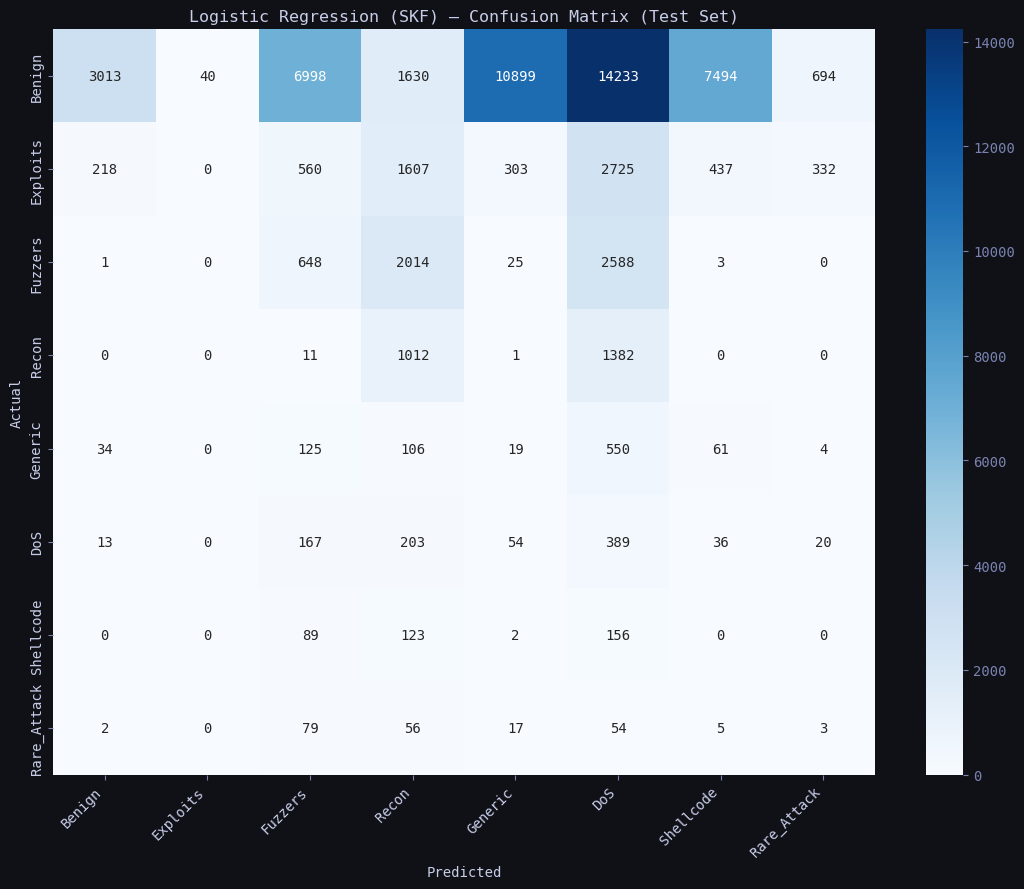

In [82]:
y_pred_lr_skf = lr_pipeline.predict(X_test)
plot_confusion_matrix(y_test, y_pred_lr_skf, LABEL_MAP, 'Logistic Regression (SKF) — Confusion Matrix (Test Set)')

#### Logistic Regression (SKF) — SHAP Feature Importance
`LinearExplainer` computes exact SHAP values for logistic regression using the pipeline's fitted scaler and model weights on the test set.

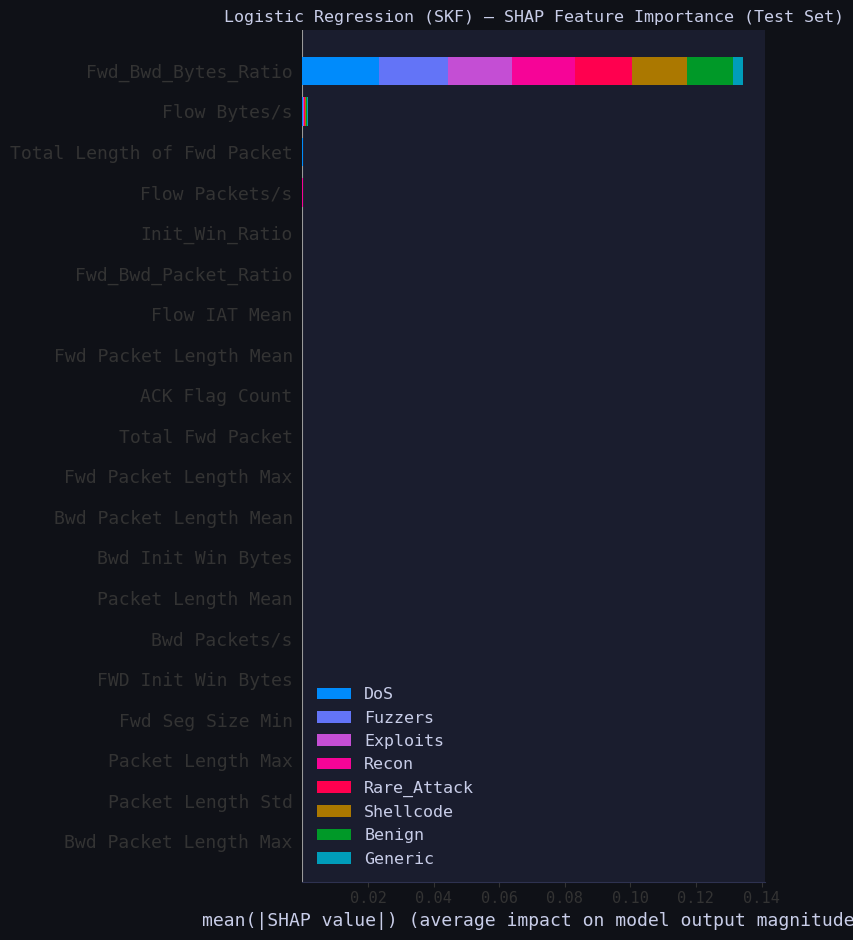

In [84]:
import shap

X_test_sample_lr = X_test.sample(n=min(500, len(X_test)), random_state=42)
# Apply the pipeline's fitted scaler — prevents re-fitting on test data
X_test_sample_lr_scaled = lr_pipeline.named_steps['scaler'].transform(X_test_sample_lr)

# LinearExplainer is exact for logistic regression; uses model coefficients directly
explainer_lr = shap.LinearExplainer(lr_pipeline.named_steps['model'], X_test_sample_lr_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_sample_lr_scaled)

plot_shap_bar(
    shap_values_lr, X_test_sample_lr_scaled,
    feature_names=X_test.columns.tolist(),
    class_names=list(LABEL_MAP.values()),
    title='Logistic Regression (SKF) — SHAP Feature Importance (Test Set)',
)

#### Logistic Regression — Precision-Recall Curves
Per-class precision-recall curves — more honest than ROC for the imbalanced class distribution.

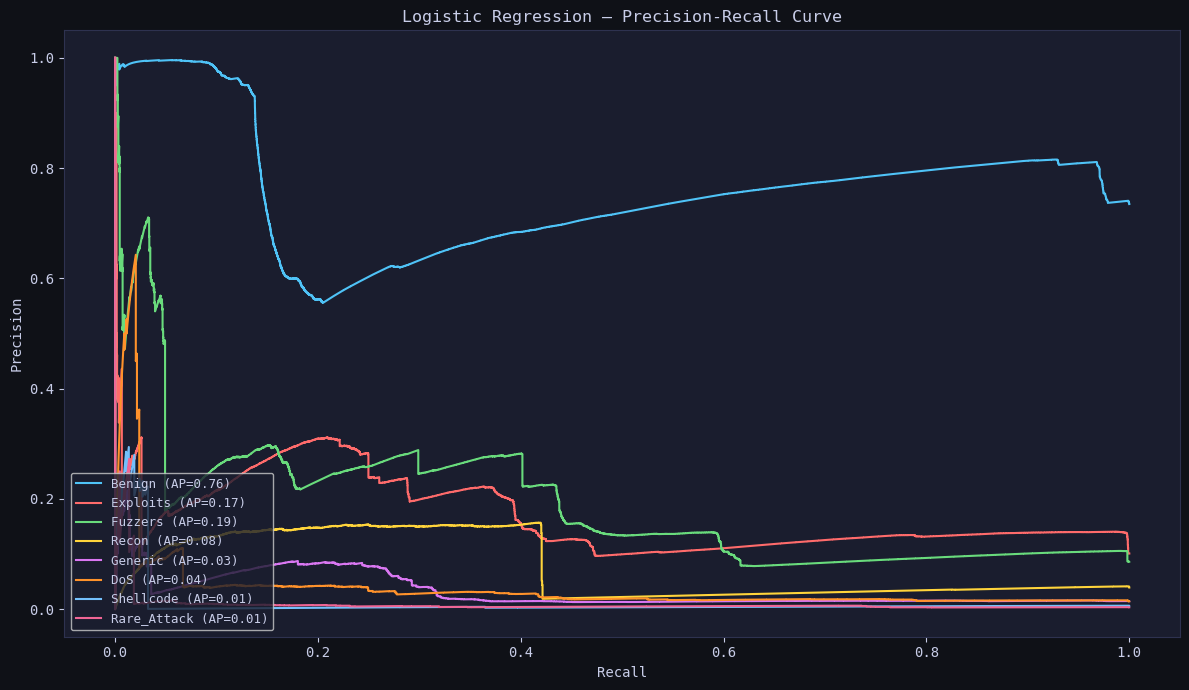

In [86]:
# label_binarize converts multi-class labels into one-vs-rest binary matrix
# PRC is more honest than ROC for imbalanced classes
classes = list(LABEL_MAP.keys())
y_test_bin = label_binarize(y_test, classes=classes)
y_score_lr = lr_pipeline.predict_proba(X_test)

plot_precision_recall(y_test_bin, y_score_lr, LABEL_MAP, PALETTE, 'Logistic Regression — Precision-Recall Curve')

#### Logistic Regression — SHAP Feature Importance
Mean absolute SHAP values per feature across all 10 classes (computed in the SKF section above).

# Random Forest

#### Random Forest — Fit & Predict
Train a Random Forest with balanced class weights on the SMOTE-augmented training set.

In [90]:
# ── Random Forest — Hyperparameter Search + Final Fit ────────────────────────

# SMOTE was applied once in Step 6 on the full training set rather than inside
# each CV fold — this avoids re-running it 24 times and cuts search time significantly.
rf_cv_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', RandomForestClassifier(
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ))
])

param_dist_rf = {
    'model__n_estimators': randint(50, 150),
    'model__max_depth':    [10, 20],
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

gs_rf = RandomizedSearchCV(
    rf_cv_pipeline,
    param_distributions=param_dist_rf,
    n_iter=8,
    cv=skf,
    scoring={
        'accuracy':    'accuracy',
        'macro_f1':    'f1_macro',
        'weighted_f1': 'f1_weighted',
    },
    refit='macro_f1',
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
    random_state=42
)

# SMOTE already ran once in Step 6 — search directly on the balanced data
gs_rf.fit(X_train, y_train)

print('=== Random Forest — RandomizedSearchCV ===')
print(f"Best params:      {gs_rf.best_params_}")
print(f"Best Macro F1:    {gs_rf.best_score_:.4f}")
res = gs_rf.cv_results_
b   = gs_rf.best_index_
print(f"Train Accuracy:   {res['mean_train_accuracy'][b]:.4f} ± {res['std_train_accuracy'][b]:.4f}")
print(f"Val  Accuracy:    {res['mean_test_accuracy'][b]:.4f} ± {res['std_test_accuracy'][b]:.4f}")
print(f"Train Macro F1:   {res['mean_train_macro_f1'][b]:.4f} ± {res['std_train_macro_f1'][b]:.4f}")
print(f"Val  Macro F1:    {res['mean_test_macro_f1'][b]:.4f} ± {res['std_test_macro_f1'][b]:.4f}")
print(f"Val  Weighted F1: {res['mean_test_weighted_f1'][b]:.4f} ± {res['std_test_weighted_f1'][b]:.4f}")

# ── Final fit using best params from search ───────────────────────────────────
best_rf_params = {k.replace('model__', ''): v for k, v in gs_rf.best_params_.items()}

rf_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', RandomForestClassifier(
        **best_rf_params,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train_res, y_train_res)

y_pred_rf = rf_pipeline.predict(X_test)

print('\n=== Random Forest — Train vs Test Score (overfitting check) ===')
print(f'  Training Score: {rf_pipeline.score(X_train, y_train):.4f}')
print(f'  Testing Score:  {rf_pipeline.score(X_test, y_test):.4f}')
print()
print('=== Random Forest — Classification Report (Test Set) ===')
print(classification_report(
    y_test, y_pred_rf,
    target_names=list(LABEL_MAP.values()),
    digits=4
))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
=== Random Forest — RandomizedSearchCV ===
Best params:      {'model__max_depth': 10, 'model__n_estimators': 70}
Best Macro F1:    0.5204
Train Accuracy:   0.8966 ± 0.0004
Val  Accuracy:    0.8947 ± 0.0005
Train Macro F1:   0.5350 ± 0.0038
Val  Macro F1:    0.5204 ± 0.0035
Val  Weighted F1: 0.8924 ± 0.0007

=== Random Forest — Train vs Test Score (overfitting check) ===
  Training Score: 0.8812
  Testing Score:  0.8800

=== Random Forest — Classification Report (Test Set) ===
              precision    recall  f1-score   support

      Benign     0.9994    0.9616    0.9801     45001
    Exploits     0.8532    0.5754    0.6873      6182
     Fuzzers     0.5510    0.8217    0.6597      5279
       Recon     0.5897    0.6284    0.6085      2406
     Generic     0.5634    0.6719    0.6129       899
         DoS     0.3436    0.2914    0.3153       882
   Shellcode     0.2052    0.5568    0.2999       370
 Rare_Attack     0.2815   

#### Random Forest — Cross-Validation
5-fold stratified cross-validation for the Random Forest.

#### Random Forest (SKF) — Confusion Matrix
Test-set confusion matrix using the pipeline fitted above.

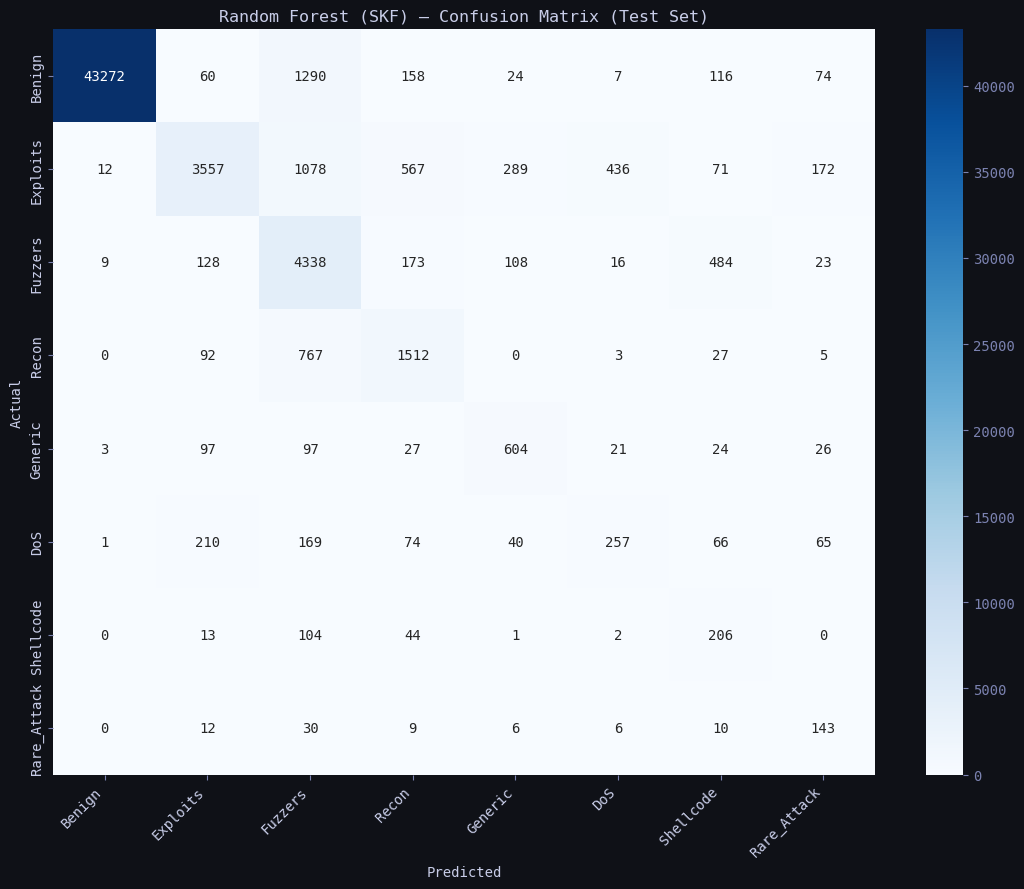

In [93]:
y_pred_rf_skf = rf_pipeline.predict(X_test)
plot_confusion_matrix(y_test, y_pred_rf_skf, LABEL_MAP, 'Random Forest (SKF) — Confusion Matrix (Test Set)')

#### Random Forest (SKF) — SHAP Feature Importance
`TreeExplainer` computes exact SHAP values for Random Forest using the pipeline's fitted scaler on the test set.

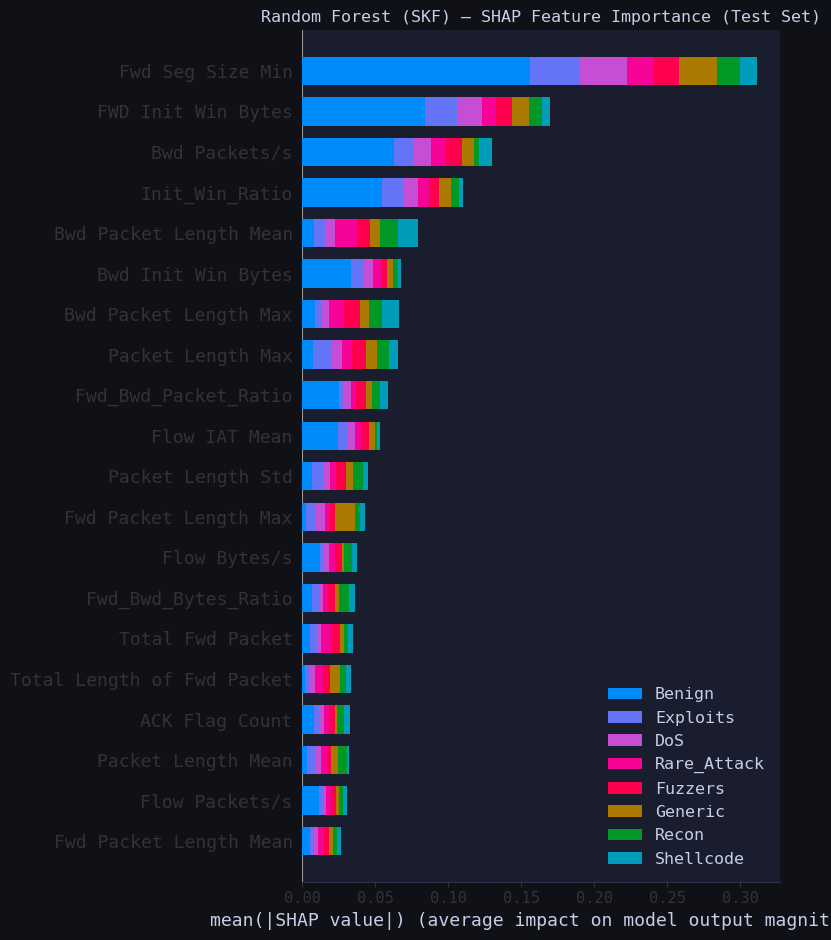

In [95]:
X_test_sample_rf = X_test.sample(n=min(500, len(X_test)), random_state=42)
# Apply the pipeline's fitted scaler — no refitting on test data
X_test_sample_rf_scaled = rf_pipeline.named_steps['scaler'].transform(X_test_sample_rf)

# TreeExplainer is exact for Random Forest; much faster than KernelExplainer
explainer_rf = shap.TreeExplainer(rf_pipeline.named_steps['model'])
shap_values_rf = explainer_rf.shap_values(X_test_sample_rf_scaled)


plot_shap_bar(
    shap_values_rf, X_test_sample_rf_scaled,
    feature_names=X_test.columns.tolist(),
    class_names=list(LABEL_MAP.values()),
    title='Random Forest (SKF) — SHAP Feature Importance (Test Set)',
)

#### Random Forest — Precision-Recall Curves
Per-class precision-recall curves for Random Forest.

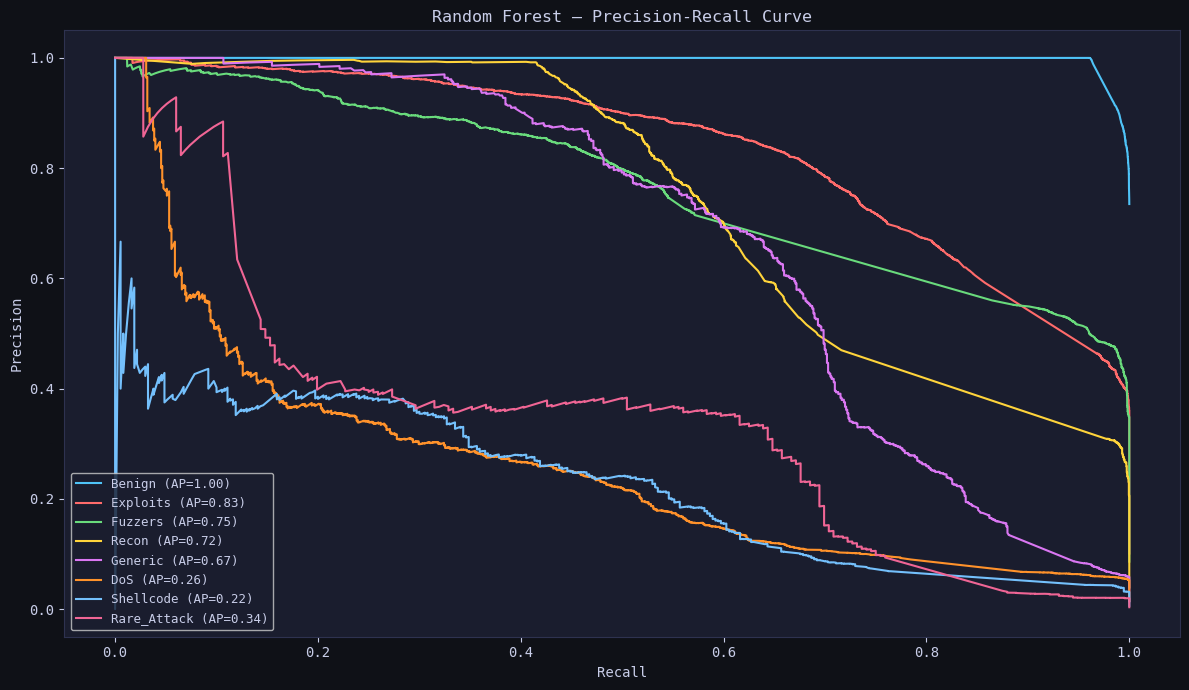

In [97]:
y_score_rf = rf_pipeline.predict_proba(X_test)
plot_precision_recall(y_test_bin, y_score_rf, LABEL_MAP, PALETTE, 'Random Forest — Precision-Recall Curve')

# XGBoost

#### XGBoost — Fit & Predict
Train XGBoost with histogram tree method and multi-class log-loss, then generate test-set predictions.

In [100]:
# ── XGBoost — Hyperparameter Search + Final Fit ──────────────────────────────

# SMOTE was applied once in Step 6 on the full training set rather than inside
# each CV fold — this avoids re-running it 24 times and cuts search time significantly.
xgb_cv_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', XGBClassifier(
        tree_method='hist',
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

param_dist_xgb = {
    'model__n_estimators':  randint(50, 150),
    'model__max_depth':     randint(3, 10),
    'model__learning_rate': loguniform(1e-3, 0.3),}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

gs_xgb = RandomizedSearchCV(
    xgb_cv_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=8,
    cv=skf,
    scoring={
        'accuracy':    'accuracy',
        'macro_f1':    'f1_macro',
        'weighted_f1': 'f1_weighted',
    },
    refit='macro_f1',
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
    random_state=42
)

# SMOTE already ran once in Step 6 — search directly on the balanced data
gs_xgb.fit(X_train, y_train)

print('=== XGBoost — RandomizedSearchCV ===')
print(f"Best params:      {gs_xgb.best_params_}")
print(f"Best Macro F1:    {gs_xgb.best_score_:.4f}")
res = gs_xgb.cv_results_
b   = gs_xgb.best_index_
print(f"Train Accuracy:   {res['mean_train_accuracy'][b]:.4f} ± {res['std_train_accuracy'][b]:.4f}")
print(f"Val  Accuracy:    {res['mean_test_accuracy'][b]:.4f} ± {res['std_test_accuracy'][b]:.4f}")
print(f"Train Macro F1:   {res['mean_train_macro_f1'][b]:.4f} ± {res['std_train_macro_f1'][b]:.4f}")
print(f"Val  Macro F1:    {res['mean_test_macro_f1'][b]:.4f} ± {res['std_test_macro_f1'][b]:.4f}")
print(f"Val  Weighted F1: {res['mean_test_weighted_f1'][b]:.4f} ± {res['std_test_weighted_f1'][b]:.4f}")

# ── Final fit using best params from search ───────────────────────────────────
best_xgb_params = {
    k.replace('model__', ''): v
    for k, v in gs_xgb.best_params_.items()
}

xgb_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', XGBClassifier(
        **best_xgb_params,
        tree_method='hist',
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train_res, y_train_res)

y_pred_xgb = xgb_pipeline.predict(X_test)

print('\n=== XGBoost — Train vs Test Score (overfitting check) ===')
print(f'  Training Score: {xgb_pipeline.score(X_train, y_train):.4f}')
print(f'  Testing Score:  {xgb_pipeline.score(X_test, y_test):.4f}')
print()
print('=== XGBoost — Classification Report (Test Set) ===')
print(classification_report(
    y_test, y_pred_xgb,
    target_names=list(LABEL_MAP.values()),
    digits=4
))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
=== XGBoost — RandomizedSearchCV ===
Best params:      {'model__learning_rate': 0.06504856968981275, 'model__max_depth': 7, 'model__n_estimators': 70}
Best Macro F1:    0.5430
Train Accuracy:   0.8983 ± 0.0003
Val  Accuracy:    0.8956 ± 0.0005
Train Macro F1:   0.5744 ± 0.0024
Val  Macro F1:    0.5430 ± 0.0043
Val  Weighted F1: 0.8944 ± 0.0006

=== XGBoost — Train vs Test Score (overfitting check) ===
  Training Score: 0.8847
  Testing Score:  0.8833

=== XGBoost — Classification Report (Test Set) ===
              precision    recall  f1-score   support

      Benign     0.9998    0.9616    0.9803     45001
    Exploits     0.8395    0.5950    0.6964      6182
     Fuzzers     0.5509    0.8432    0.6664      5279
       Recon     0.6075    0.6131    0.6103      2406
     Generic     0.5931    0.6908    0.6382       899
         DoS     0.3429    0.3129    0.3272       882
   Shellcode     0.2235    0.4676    0.3024       370


#### XGBoost (SKF) — Confusion Matrix
Test-set confusion matrix using the pipeline fitted above.

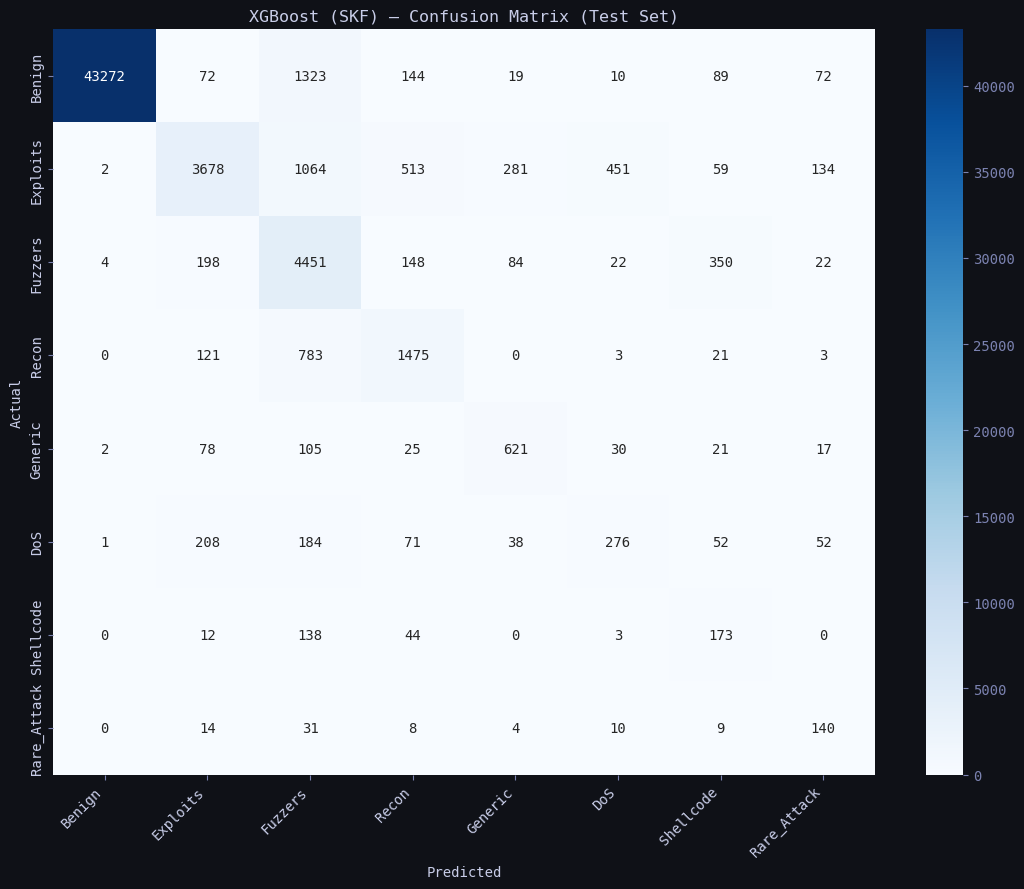

In [102]:
y_pred_xgb_skf = xgb_pipeline.predict(X_test)
plot_confusion_matrix(y_test, y_pred_xgb_skf, LABEL_MAP, 'XGBoost (SKF) — Confusion Matrix (Test Set)')

#### XGBoost (SKF) — SHAP Feature Importance
`TreeExplainer` computes exact SHAP values for XGBoost using the pipeline's fitted scaler on the test set.

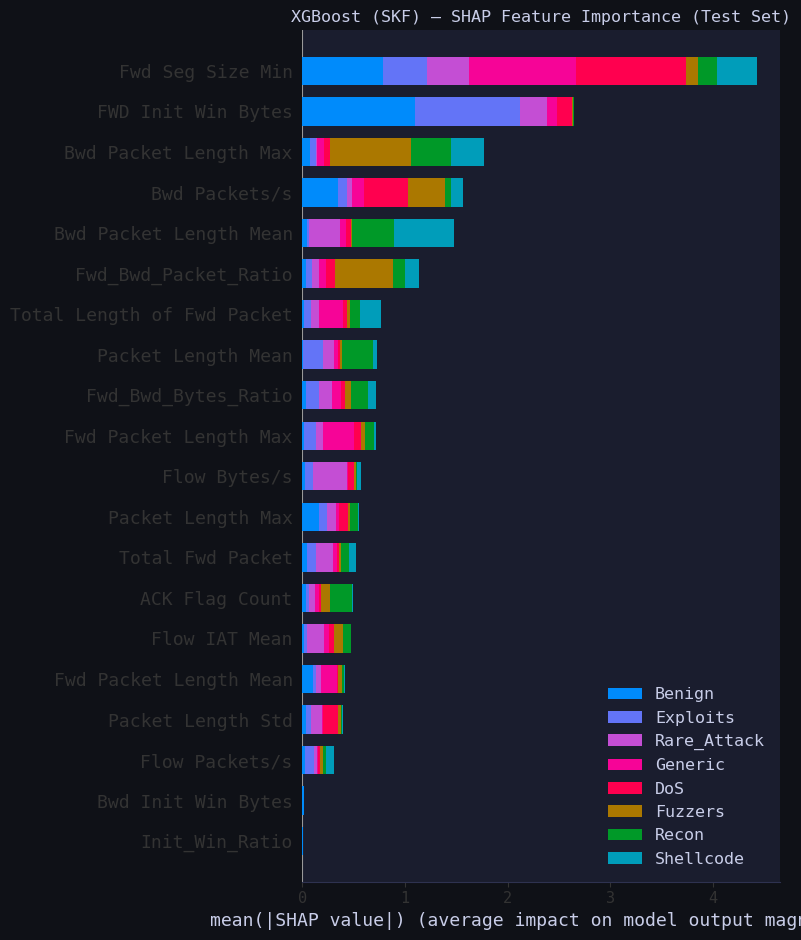

In [104]:
X_test_sample_xgb = X_test.sample(n=min(500, len(X_test)), random_state=42)
# Apply the pipeline's fitted scaler — no refitting on test data
X_test_sample_xgb_scaled = xgb_pipeline.named_steps['scaler'].transform(X_test_sample_xgb)

# XGBoost's native SHAP implementation via TreeExplainer — exact and fast
explainer_xgb = shap.TreeExplainer(xgb_pipeline.named_steps['model'])
shap_values_xgb = explainer_xgb.shap_values(X_test_sample_xgb_scaled)

plot_shap_bar(
    shap_values_xgb, X_test_sample_xgb_scaled,
    feature_names=X_test.columns.tolist(),
    class_names=list(LABEL_MAP.values()),
    title='XGBoost (SKF) — SHAP Feature Importance (Test Set)',
)

#### XGBoost — Precision-Recall Curves
Per-class precision-recall curves for XGBoost.

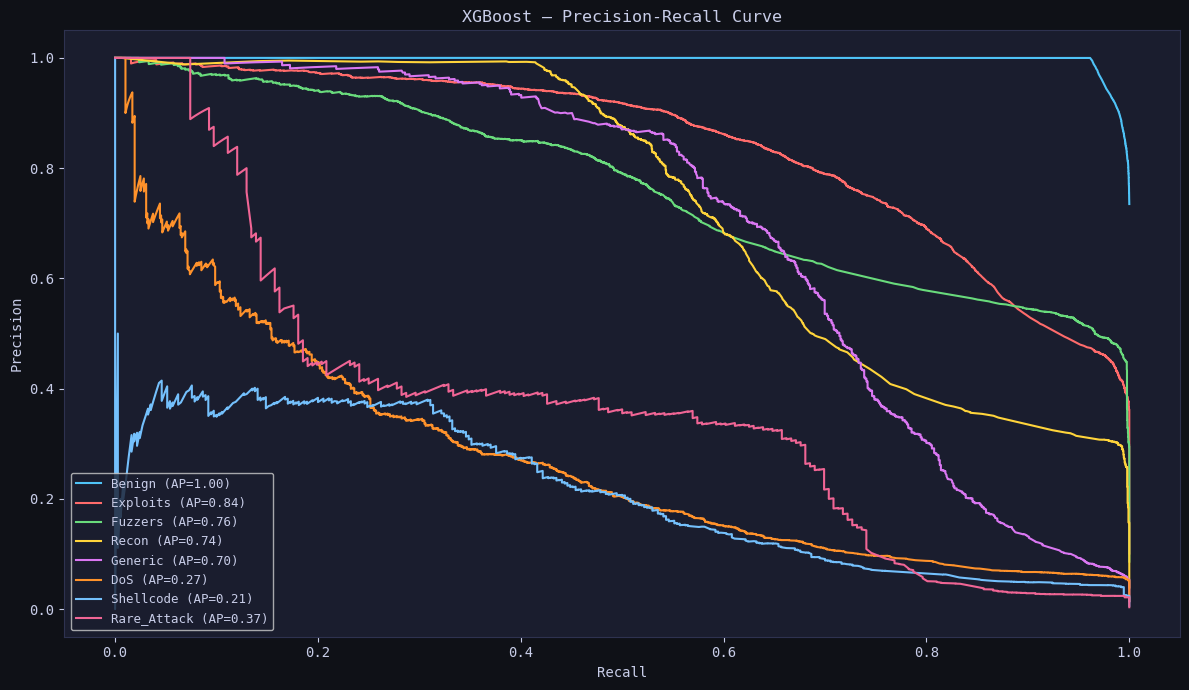

In [106]:
y_score_xgb = xgb_pipeline.predict_proba(X_test)
plot_precision_recall(y_test_bin, y_score_xgb, LABEL_MAP, PALETTE, 'XGBoost — Precision-Recall Curve')

# MLP

#### MLP — Model Definition
Define `TabularDataset` (wraps scaled arrays as PyTorch tensors) and `MLPClassifier` — stacked Linear → ReLU → Dropout blocks with a final classifier head.

In [109]:
# Wraps numpy arrays as a PyTorch Dataset so DataLoader can batch them
class TabularDataset(Dataset):
    def __init__(self, X, y):
        # Convert feature array to float32 tensor
        self.X = torch.tensor(X, dtype=torch.float32)
        # Convert labels to long tensor required by CrossEntropyLoss
        self.y = torch.tensor(np.array(y), dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# True MLP: num_layers blocks of Linear → ReLU → Dropout(0.3), then a classifier head
class MLPClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        layers = []
        in_dim = input_size
        for _ in range(num_layers):
            layers += [nn.Linear(in_dim, hidden_size), nn.ReLU(), nn.Dropout(0.3)]
            in_dim = hidden_size
        layers.append(nn.Linear(hidden_size, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


#### MLP — Build DataLoaders & Train
Create DataLoaders, instantiate the MLP, and run the training loop for 5 epochs.

In [111]:
# Use GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Wrap training arrays in the PyTorch Dataset
train_ds = TabularDataset(X_train_res_scaled, y_train_res)
# Wrap test arrays in the PyTorch Dataset
test_ds  = TabularDataset(X_test_scaled,  y_test)
# Shuffle training batches each epoch to prevent order bias
train_loader = DataLoader(train_ds, batch_size=2048, shuffle=True,  num_workers=0)
# No shuffle for evaluation — order does not affect accuracy
test_loader  = DataLoader(test_ds,  batch_size=2048, shuffle=False, num_workers=0)

# Instantiate MLP and move all weights to the selected device
mlp_model = MLPClassifier(
    input_size=X_train_scaled.shape[1],
    hidden_size=128,
    num_layers=2,
    num_classes=8
).to(device)

# Cross-entropy loss for 10-class classification
criterion = nn.CrossEntropyLoss()
# Adam optimiser with lr=0.001
optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3)

EPOCHS = 5
mlp_train_accs, mlp_train_losses = [], []

for epoch in range(EPOCHS):
    # Enable training mode (activates dropout)
    mlp_model.train()
    total_loss = 0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        # Clear gradients accumulated from the previous batch
        optimizer.zero_grad()
        logits = mlp_model(X_batch)
        # Compute cross-entropy loss and backpropagate
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        # Accumulate correct predictions for training accuracy
        correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total += len(y_batch)
    epoch_acc  = correct / total
    epoch_loss = total_loss / len(train_loader)
    mlp_train_accs.append(epoch_acc)
    mlp_train_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{EPOCHS}  Loss: {epoch_loss:.4f}  Train Acc: {epoch_acc:.4f}')

Using device: cpu
Epoch 1/5  Loss: 8.8405  Train Acc: 0.5538
Epoch 2/5  Loss: 2.0196  Train Acc: 0.6093
Epoch 3/5  Loss: 1.0728  Train Acc: 0.6514
Epoch 4/5  Loss: 0.9450  Train Acc: 0.6667
Epoch 5/5  Loss: 0.9126  Train Acc: 0.6726


#### MLP — Evaluate
Switch to eval mode and collect per-batch predictions and class probabilities on the test set.

In [113]:
# Disable dropout for deterministic inference
mlp_model.eval()
all_preds, all_probs = [], []

# Skip gradient tracking to save memory during evaluation
with torch.no_grad():
    for X_batch, _ in test_loader:
        # Forward pass to get raw class scores
        logits = mlp_model(X_batch.to(device))
        # Take the highest-scoring class as the prediction
        all_preds.append(logits.argmax(dim=1).cpu())
        # Convert logits to probabilities for PR curve computation
        all_probs.append(torch.softmax(logits, dim=1).cpu())

# Concatenate all batch predictions into a single array
y_pred_mlp  = torch.cat(all_preds).numpy()
# Concatenate all batch probabilities into a single array
y_score_mlp = torch.cat(all_probs).numpy()

# Evaluate on the training set to expose any train/test gap (overfitting check)
train_preds_all = []
with torch.no_grad():
    for X_batch, _ in DataLoader(train_ds, batch_size=2048, shuffle=False, num_workers=0):
        logits = mlp_model(X_batch.to(device))
        train_preds_all.append(logits.argmax(dim=1).cpu())
y_pred_mlp_train = torch.cat(train_preds_all).numpy()

train_acc = accuracy_score(np.array(y_train_res), y_pred_mlp_train)
test_acc  = accuracy_score(y_test, y_pred_mlp)
gap = train_acc - test_acc

print('=== MLP — Train vs Test Score (overfitting check) ===')
print(f'  Training Accuracy: {train_acc:.4f}')
print(f'  Testing  Accuracy: {test_acc:.4f}')
print(f'  Gap (train-test):  {gap:.4f}  {"possible overfit" if gap > 0.05 else "looks healthy"}')
print()
print('=== MLP — Classification Report (Test Set) ===')
print(classification_report(
    y_test, y_pred_mlp,
    target_names=list(LABEL_MAP.values()),
    digits=4
))

=== MLP — Train vs Test Score (overfitting check) ===
  Training Accuracy: 0.6869
  Testing  Accuracy: 0.7761
  Gap (train-test):  -0.0893  looks healthy

=== MLP — Classification Report (Test Set) ===
              precision    recall  f1-score   support

      Benign     0.9983    0.9357    0.9660     45001
    Exploits     0.8132    0.3471    0.4866      6182
     Fuzzers     0.4120    0.0705    0.1203      5279
       Recon     0.2049    0.9451    0.3368      2406
     Generic     0.3006    0.4672    0.3659       899
         DoS     0.1857    0.0147    0.0273       882
   Shellcode     0.1441    0.2297    0.1771       370
 Rare_Attack     0.0458    0.5000    0.0839       216

    accuracy                         0.7761     61235
   macro avg     0.3881    0.4388    0.3205     61235
weighted avg     0.8674    0.7761    0.7898     61235



#### MLP — Confusion Matrix
Plot the confusion matrix on the held-out test set.

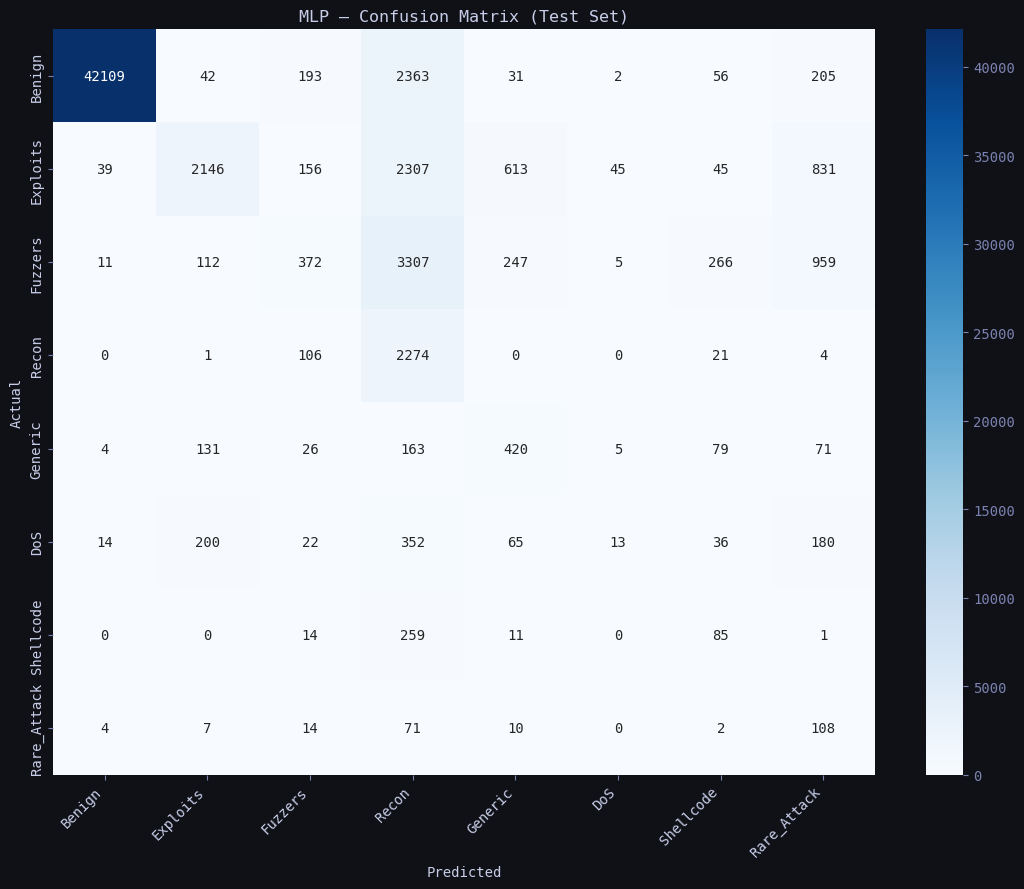

In [115]:
plot_confusion_matrix(y_test, y_pred_mlp, LABEL_MAP, 'MLP — Confusion Matrix (Test Set)')

#### MLP — Precision-Recall Curves
Per-class precision-recall curves for the MLP — more informative than ROC for imbalanced classes.

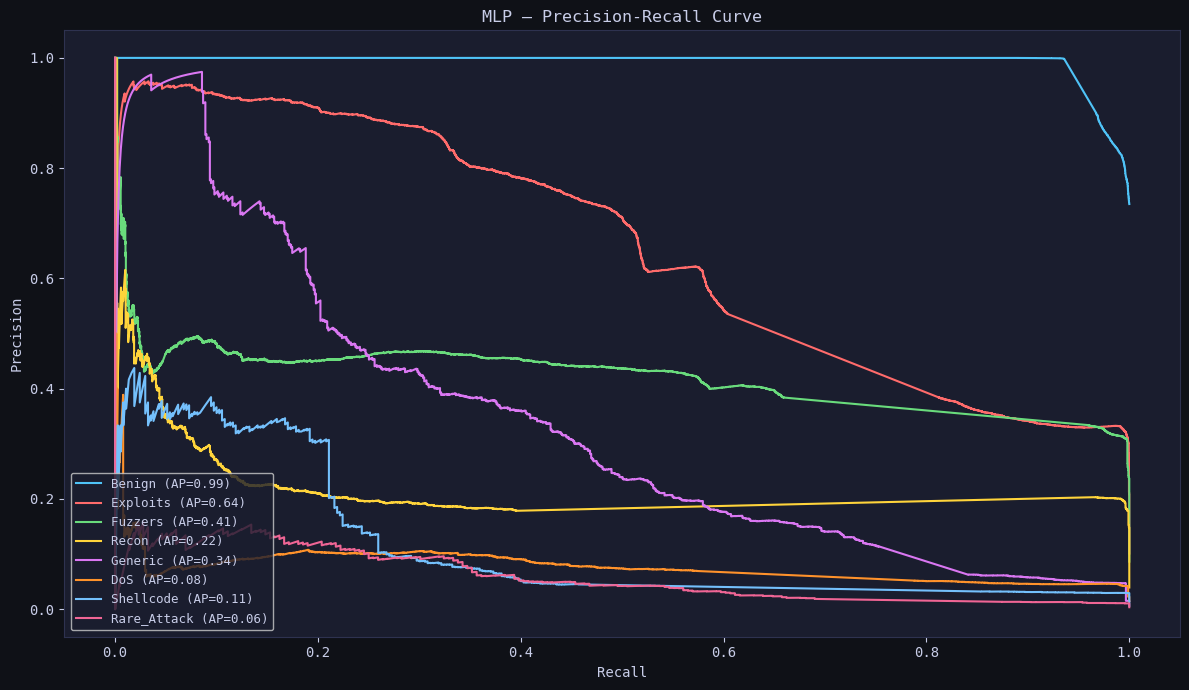

In [117]:
plot_precision_recall(y_test_bin, y_score_mlp, LABEL_MAP, PALETTE, 'MLP — Precision-Recall Curve')

#### MLP — SHAP Feature Importance
`GradientExplainer` approximates SHAP values for the PyTorch MLP via integrated gradients on a 300-sample slice of the test set and aggregates across all 10 output classes. (`DeepExplainer` / DeepLIFT is the alternative — both are valid for PyTorch; `GradientExplainer` is more stable when the network contains dropout layers.)

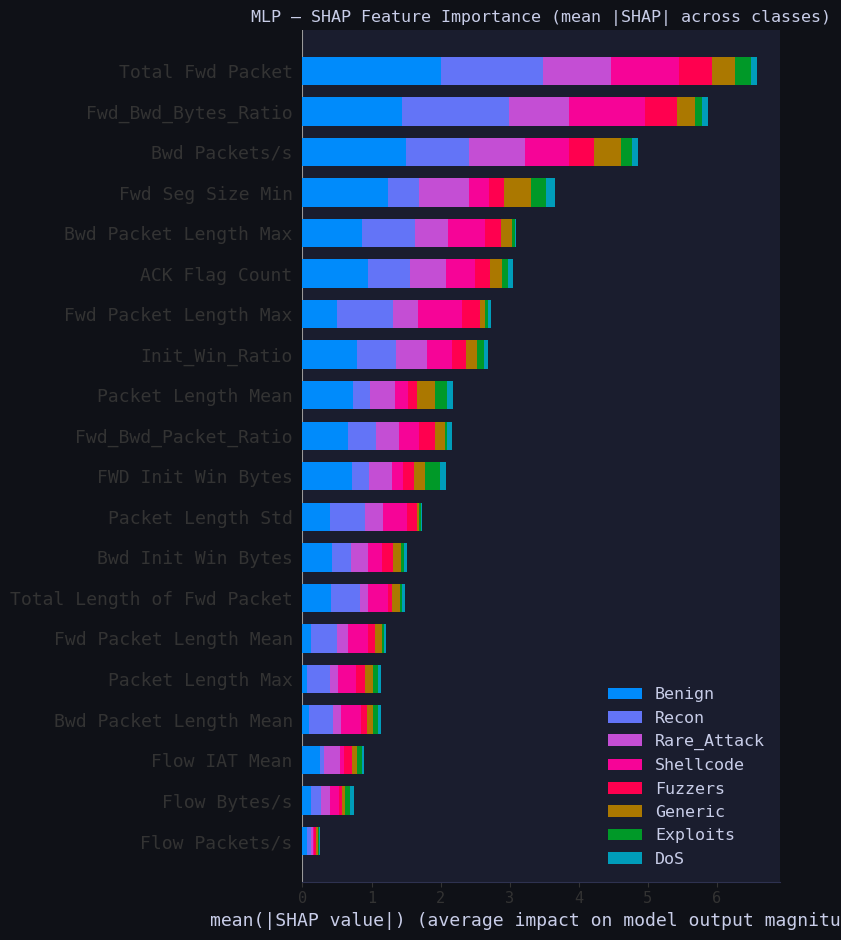

In [119]:
mlp_model.eval()
background_mlp = torch.FloatTensor(X_train_res_scaled[:100])
# GradientExplainer (integrated gradients) — preferred over DeepExplainer when dropout is present
explainer_mlp_shap = shap.GradientExplainer(mlp_model, background_mlp)
sample_scaled_mlp = torch.FloatTensor(X_test_scaled[100:400])
shap_values_mlp_deep = explainer_mlp_shap.shap_values(sample_scaled_mlp)
# shap_values_mlp_deep is a list of 8 arrays each (300, 20) — pass directly to summary_plot
plot_shap_bar(
    shap_values_mlp_deep, X_test_scaled[100:400],
    feature_names=X_test.columns.tolist(),
    class_names=list(LABEL_MAP.values()),
    title='MLP — SHAP Feature Importance (mean |SHAP| across classes)',
)

### Bridge — Collect Results & Build Named DataFrames
Aggregate each model's **test-set weighted F1** into `results`, then wrap the scaled numpy arrays back into pandas DataFrames so column names are preserved for all downstream cells.

In [121]:
from sklearn.metrics import f1_score

# Test-set weighted F1 for all four models — apples-to-apples comparison
results = [
    {"name": "Logistic Regression", "weighted_f1": f1_score(y_test, y_pred_lr,  average="weighted")},
    {"name": "Random Forest",       "weighted_f1": f1_score(y_test, y_pred_rf,  average="weighted")},
    {"name": "XGBoost",             "weighted_f1": f1_score(y_test, y_pred_xgb, average="weighted")},
    {"name": "MLP",                 "weighted_f1": f1_score(y_test, y_pred_mlp, average="weighted")},
]

# Restore column names lost when RobustScaler returned a numpy array
X_train_final = pd.DataFrame(X_train_res_scaled, columns=X_train_res.columns)
X_test_final  = pd.DataFrame(X_test_scaled,       columns=X_test.columns)

print("Model Comparison — Test-Set Weighted F1:")
for r in results:
    print(f"  {r['name']:<22}  weighted_f1={r['weighted_f1']:.4f}")
print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape:  {X_test_final.shape}")


Model Comparison — Test-Set Weighted F1:
  Logistic Regression     weighted_f1=0.1090
  Random Forest           weighted_f1=0.8872
  XGBoost                 weighted_f1=0.8896
  MLP                     weighted_f1=0.7898
X_train_final shape: (315846, 20)
X_test_final shape:  (61235, 20)


### Threshold Sensitivity — Attack Probability
For each threshold `t` in `[0.50, 0.55, …, 0.95]`, a sample is flagged as an attack when `P(attack) = 1 − P(Benign) ≥ t`; otherwise it is classified as Benign. The table and plots show how macro F1, attack recall, and attack precision change as the confidence bar rises.


=== Logistic Regression ===
 Threshold  Accuracy  Macro F1  Weighted F1  Attack Prec  Attack Rec  Attack F1
    0.5000    0.0338    0.0440       0.0171       0.2651      1.0000     0.4191
    0.5500    0.0338    0.0440       0.0171       0.2651      1.0000     0.4191
    0.6000    0.0338    0.0440       0.0171       0.2651      1.0000     0.4191
    0.6500    0.0338    0.0440       0.0171       0.2651      1.0000     0.4191
    0.7000    0.0338    0.0440       0.0171       0.2651      1.0000     0.4191
    0.7500    0.0338    0.0440       0.0171       0.2651      1.0000     0.4191
    0.8000    0.0340    0.0441       0.0175       0.2652      1.0000     0.4192
    0.8500    0.0344    0.0442       0.0184       0.2653      1.0000     0.4193
    0.9000    0.7350    0.1131       0.6252       0.9191      0.0217     0.0424
    0.9500    0.7349    0.1108       0.6245       0.9190      0.0161     0.0316

=== Random Forest ===
 Threshold  Accuracy  Macro F1  Weighted F1  Attack Prec  Attack Rec

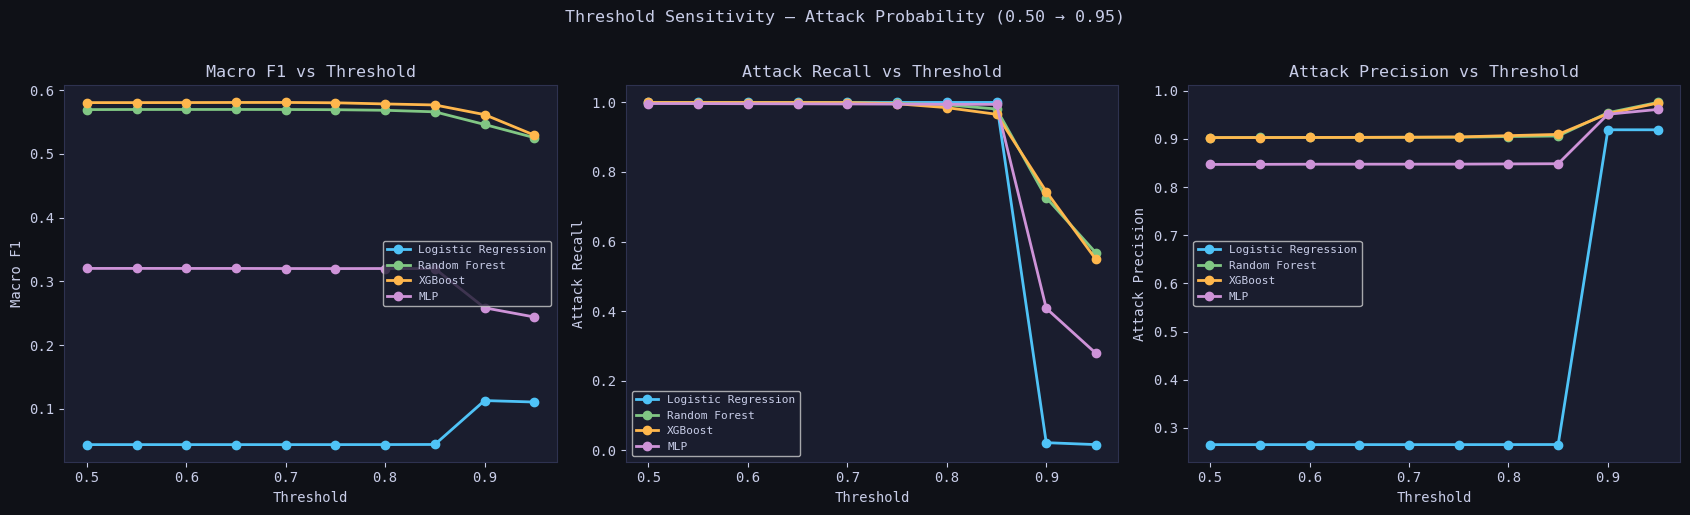

In [123]:

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

BENIGN_IDX = 0  # class 0 is Benign; all others are attacks

thresholds = np.round(np.arange(0.50, 0.96, 0.05), 2)

models = {
    'Logistic Regression': y_score_lr,
    'Random Forest':       y_score_rf,
    'XGBoost':             y_score_xgb,
    'MLP':                 y_score_mlp,
}

def threshold_predict(proba, t):
    # If attack probability (= 1 - P(Benign)) >= t, pick the top attack class; else Benign
    attack_prob = 1.0 - proba[:, BENIGN_IDX]
    return np.where(
        attack_prob >= t,
        proba[:, 1:].argmax(axis=1) + 1,  # +1 shifts attack-column indices back to class labels
        BENIGN_IDX,
    )

records = []
for name, proba in models.items():
    for t in thresholds:
        preds = threshold_predict(proba, t)
        y_bin_true = (y_test != BENIGN_IDX).astype(int)
        y_bin_pred = (preds  != BENIGN_IDX).astype(int)
        records.append({
            'Model':       name,
            'Threshold':   t,
            'Accuracy':    accuracy_score(y_test, preds),
            'Macro F1':    f1_score(y_test, preds, average='macro',    zero_division=0),
            'Weighted F1': f1_score(y_test, preds, average='weighted', zero_division=0),
            'Attack Prec': precision_score(y_bin_true, y_bin_pred, zero_division=0),
            'Attack Rec':  recall_score(y_bin_true, y_bin_pred, zero_division=0),
            'Attack F1':   f1_score(y_bin_true, y_bin_pred, zero_division=0),
        })

df_thresh = pd.DataFrame(records)

for name in models:
    sub = df_thresh[df_thresh['Model'] == name].drop(columns='Model')
    print(f'\n=== {name} ===')
    print(sub.to_string(index=False, float_format='{:.4f}'.format))

plot_threshold_sensitivity(df_thresh, models)

In [124]:
results = [
    {"name": "Logistic Regression", "weighted_f1": f1_score(y_test, y_pred_lr,   average="weighted")},
    {"name": "Random Forest",       "weighted_f1": f1_score(y_test, y_pred_rf,   average="weighted")},
    {"name": "XGBoost",             "weighted_f1": f1_score(y_test, y_pred_xgb,  average="weighted")},
    {"name": "MLP",                "weighted_f1": f1_score(y_test, y_pred_mlp,  average="weighted")},
] 
results

[{'name': 'Logistic Regression', 'weighted_f1': 0.10896120599756509},
 {'name': 'Random Forest', 'weighted_f1': 0.8871975620643128},
 {'name': 'XGBoost', 'weighted_f1': 0.8895720324460706},
 {'name': 'MLP', 'weighted_f1': 0.78976736194601}]

In [126]:
import joblib
import json
from datetime import datetime

# ── 1. Pick best sklearn model by weighted F1 ────────────────────────────────
sklearn_results = [r for r in results if r["name"] != "MLP"]
best_result     = max(sklearn_results, key=lambda r: r["weighted_f1"])
best_model_name = best_result["name"]

model_lookup = {
    "Logistic Regression": lr_pipeline,
    "Random Forest":       rf_pipeline,
    "XGBoost":             xgb_pipeline,
}
best_clf = model_lookup[best_model_name]

print(f"Best model: {best_model_name}  (weighted F1 = {best_result['weighted_f1']:.4f})")

# ── 2. Save artifacts ────────────────────────────────────────────────────────
import os
os.makedirs("artifacts", exist_ok=True)

joblib.dump(best_clf, "artifacts/model.pkl")

feature_cols = X_test_final.columns.tolist()
with open("artifacts/features.json", "w") as f:
    json.dump(feature_cols, f)

label_map_str = {str(k): v for k, v in LABEL_MAP.items()}
with open("artifacts/label_map.json", "w") as f:
    json.dump(label_map_str, f, indent=2)

model_card = {
    "model_name":   best_model_name,
    "dataset":      "UNSW-NB15 2024",
    "weighted_f1":  best_result["weighted_f1"],
    "trained_at":   datetime.utcnow().isoformat(),
    "features":     len(feature_cols),
    "smote_applied": True,
    "scaler":       "RobustScaler (inside pipeline)",
    "classes":      label_map_str,
}
with open("artifacts/model_card.json", "w") as f:
    json.dump(model_card, f, indent=2)

print("Saved: artifacts/model.pkl")
print("Saved: artifacts/features.json")
print("Saved: artifacts/label_map.json")
print("Saved: artifacts/model_card.json")

Best model: XGBoost  (weighted F1 = 0.8896)
Saved: artifacts/model.pkl
Saved: artifacts/features.json
Saved: artifacts/label_map.json
Saved: artifacts/model_card.json


In [127]:
from elasticsearch import Elasticsearch
from elasticsearch.helpers import bulk
from datetime import datetime, timedelta

es = Elasticsearch("http://localhost:9200")

# Build alert dataframe from test set results
alert_df = pd.DataFrame({
    'attack_score': 1.0 - y_score_xgb[:, 0],
    'pred_label':   [LABEL_MAP[i] for i in y_pred_xgb],
    'true_label':   [LABEL_MAP[i] for i in y_test],
    'alert_tier':   ['HIGH' if s >= 0.85 else 'MEDIUM' if s >= 0.50 else 'LOW' 
                     for s in (1.0 - y_score_xgb[:, 0])],
    'action':       ['ALERT - Escalate immediately' if s >= 0.85 
                     else 'MONITOR - Flag for review' if s >= 0.50 
                     else 'LOG - Routine logging' 
                     for s in (1.0 - y_score_xgb[:, 0])]
})

# Bulk ingest
def generate_docs(df):
    base_time = datetime.utcnow() - timedelta(hours=len(df)/3600)
    for i, (_, row) in enumerate(df.iterrows()):
        yield {
            "_index": "ids-alerts",
            "_source": {
                "@timestamp": (base_time + timedelta(seconds=i)).isoformat(),
                "attack_score": float(row["attack_score"]),
                "alert_tier":   row["alert_tier"],
                "pred_label":   row["pred_label"],
                "true_label":   row["true_label"],
                "action":       row["action"],
            }
        }

success, failed = bulk(es, generate_docs(alert_df))
print(f"Ingested {success} alerts | Failed: {failed}")

Ingested 61235 alerts | Failed: []


http://localhost:5601

docker run -d --name elasticsearch \
  -p 9200:9200 \
  -e "discovery.type=single-node" \
  -e "xpack.security.enabled=false" \
  docker.elastic.co/elasticsearch/elasticsearch:8.13.0

docker run -d --name kibana \
  -p 5601:5601 \
  -e "ELASTICSEARCH_HOSTS=http://elasticsearch:9200" \
  --link elasticsearch \
  docker.elastic.co/kibana/kibana:8.13.0

docker start elasticsearch

docker start kibana 

http://localhost:5601

# IDS Project — Full Build Roadmap
> **Core thesis:** A behavioral anomaly detector that analyzes statistical patterns across network flows to identify attack behavior — not individual packets, not signatures. Catches novel variants of known attack classes by learning what attacks *look like* over time.

---

## Foundation

| # | Phase | Time | Details |
|---|-------|------|---------|
| 1 | **Save model artifacts** | 30 min | `joblib.dump` best model + scaler, save feature col order as JSON, write model card. ⚠️ Do this first — everything else depends on it |
| 2 | **Reduce model runtime** | 3–5 hrs | Profile all 4 models; tune RF `max_depth` / `n_jobs`; sweep XGBoost `n_estimators`; benchmark MLP batch size. Pick best accuracy/speed tradeoff before freezing the model |

---

## The Bridge — Raw Traffic → Behavioral Features

| # | Phase | Time | Details |
|---|-------|------|---------|
| 3 | **Install + verify CICFlowMeter** | 1–2 hrs | Install Java, download CICFlowMeter JAR, run against a sample PCAP, confirm CSV output column names match training data exactly. ⚠️ CICFlowMeter collapses raw packets into the flow-level behavioral statistics your model was trained on — get this working in isolation first |
| 4 | **CICFlowMeter output cleaning layer** | 1–2 hrs | Strip column name spaces, fix casing, replace `Infinity`/`NaN` with 0, assert all 20 features present, align to saved feature col JSON. Without this, predictions will be silently wrong |
| 5 | **Validate feature distributions** | 1–2 hrs | Run CICFlowMeter on a known PCAP, compare output feature distributions against training data. ⚠️ This catches the core risk: CICFlowMeter computing behavioral features slightly differently on live traffic vs training data |

---

## Upload Mode — Forensic / Offline Behavioral Analysis

| # | Phase | Time | Details |
|---|-------|------|---------|
| 6 | **pyshark PCAP handler** | 1–2 hrs | pyshark validates + saves uploaded PCAP to temp path → CICFlowMeter extracts flow behavioral stats → cleaning layer → scaler → model classifies each flow. pyshark's only job is file handling |
| 7 | **End-to-end upload pipeline test** | 1–2 hrs | Upload a real PCAP → full pipeline → predictions. Use Wireshark sample PCAPs with known traffic types to verify behavioral patterns are classified correctly |

---

## Live Mode — Real-Time Behavioral Monitoring

| # | Phase | Time | Details |
|---|-------|------|---------|
| 8 | **pyshark live capture + rolling window** | 2–3 hrs | `pyshark.LiveCapture` buffers packets for N seconds → dumps to temp PCAP → same pipeline as upload mode. Model detects behavioral anomalies across completed flows every ~30s. This latency is normal — behavioral detection operates on flow patterns, not individual packets |
| 9 | **Live pipeline test** | 1 hr | Capture your own network traffic, confirm behavioral anomalies are flagged correctly, tune the rolling window interval. ★ This is the interview demo moment — live traffic classified in near-real time |

---

## Application Layer

| # | Phase | Time | Details |
|---|-------|------|---------|
| 10 | **FastAPI inference API** | 2–3 hrs | `POST /predict` for PCAP upload, `GET /live` to start/stop live behavioral monitoring, returns per-flow attack classifications + alert tiers as JSON |
| 11 | **Streamlit dashboard** | 2–3 hrs | PCAP upload + live capture toggle, flow classification table, alert tier badges, attack class distribution chart — pure Python |
| 12 | **Elasticsearch ingestion** | 2–3 hrs | Index schema + bulk ingest behavioral alerts. Elasticsearch enables tracking attack patterns over time — core to the behavioral detection thesis |
| 13 | **Kibana dashboards** | 2–3 hrs | Alert tier pie, attack class bar, behavioral score over time line, HIGH tier data table |

---

## Deployment + Portfolio

| # | Phase | Time | Details |
|---|-------|------|---------|
| 14 | **Docker Compose** | 3–5 hrs | 5 services: FastAPI, Streamlit, Elasticsearch, Kibana, Nginx reverse proxy. ★ Biggest single resume upgrade — turns a notebook into a deployable behavioral IDS |
| 15 | **README + write-up** | 2–3 hrs | Architecture diagram, setup instructions, design decisions, limitations section. Explain why flow-based behavioral detection complements signature-based tools like Snort/Suricata |

---

## Summary

| | |
|---|---|
| **Total estimate** | 4–5 focused weekends |
| **What the model does** | Classifies network flows as Benign or one of 9 attack types based on behavioral statistics |
| **Detection latency** | ~30–40 seconds — normal for behavioral flow analysis, not a flaw |
| **Critical path** | Phases 3–5 — validate CICFlowMeter feature output before building anything around it |
| **Upload before live** | Prove behavioral classification works on known PCAPs before trusting it on live traffic |
| **Start today** | Phase 1 — save model artifacts (30 min, unblocks everything) |